In [34]:
# kd_vgg_cifar100.py
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
from torchvision.models import vgg11_bn, vgg16_bn
from tqdm import tqdm
import matplotlib.pyplot as plt
import numpy as np

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


In [35]:

# ----------------------------
# Data preparation (CIFAR-100)
# ----------------------------
def get_cifar100_loaders(batch_size=128, num_workers=4):
    # Training transforms: standard for CIFAR-100
    transform_train = transforms.Compose([
        transforms.RandomCrop(32, padding=4),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5071, 0.4867, 0.4408],
                             std=[0.2675, 0.2565, 0.2761]),
    ])
    transform_test = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5071, 0.4867, 0.4408],
                             std=[0.2675, 0.2565, 0.2761]),
    ])

    trainset = torchvision.datasets.CIFAR100(root='./data', train=True, download=True, transform=transform_train)
    testset = torchvision.datasets.CIFAR100(root='./data', train=False, download=True, transform=transform_test)

    trainloader = DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=num_workers, pin_memory=True)
    testloader = DataLoader(testset, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True)
    return trainloader, testloader


In [36]:

# ----------------------------
# Model Utilities
# ----------------------------
def get_vgg_model(model_type='vgg11', num_classes=100):
    if model_type == 'vgg11':
        model = vgg11_bn(pretrained=False)
    elif model_type == 'vgg16':
        model = vgg16_bn(pretrained=False)
    else:
        raise ValueError("Unknown model_type")
    # adjust classifier for 100 classes
    model.classifier[6] = nn.Linear(in_features=4096, out_features=num_classes)
    return model

# ----------------------------
# Metrics / accuracy
# ----------------------------
def calculate_accuracy(outputs, targets, topk=(1, 5)):
    # outputs: [B, C], targets: [B]
    maxk = max(topk)
    batch_size = targets.size(0)

    _, pred = outputs.topk(maxk, dim=1, largest=True, sorted=True)  # [B, maxk]
    pred = pred.t()  # [maxk, B]
    correct = pred.eq(targets.view(1, -1).expand_as(pred))  # [maxk, B]

    res = []
    for k in topk:
        correct_k = correct[:k].reshape(-1).float().sum(0, keepdim=True)
        res.append(correct_k.mul_(100.0 / batch_size).item())
    return res  # list [top1, top5]


In [ ]:

# ----------------------------
# Loss: KD (as specified)
# ----------------------------
def distillation_loss(student_logits, teacher_logits, targets, T=3.0, alpha=0.6):
    # Hard label CE
    ce = nn.CrossEntropyLoss()(student_logits, targets)
  
    s_log = nn.functional.log_softmax(student_logits / T, dim=1)
    t_prob = nn.functional.softmax(teacher_logits / T, dim=1)
    kd = nn.functional.kl_div(s_log, t_prob, reduction='batchmean') * (T * T)
    loss = (1.0 - alpha) * ce + alpha * kd
    return loss, ce, kd

# ----------------------------
# Training (independent student)
# ----------------------------
def train_student_independent(model, trainloader, testloader, epochs=20, lr=0.01, batch_print=False):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=5e-4)
    scheduler = optim.lr_scheduler.MultiStepLR(optimizer, milestones=[15, 20], gamma=0.1)

    history = {'train_loss': [], 'train_top1': [], 'train_top5': [],
               'test_loss': [], 'test_top1': [], 'test_top5': []}

    for epoch in range(epochs):
        # Train
        model.train()
        running_loss = 0.0
        running_top1 = running_top5 = 0.0
        total = 0

        pbar = tqdm(trainloader, desc=f'Epoch {epoch+1}/{epochs} [Train]')
        for inputs, targets in pbar:
            inputs, targets = inputs.to(device), targets.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()

            bs = inputs.size(0)
            running_loss += loss.item() * bs
            t1, t5 = calculate_accuracy(outputs, targets)
            running_top1 += t1 * bs
            running_top5 += t5 * bs
            total += bs

            if batch_print:
                pbar.set_postfix({'loss': f'{loss.item():.3f}', 'top1': f'{t1:.2f}%', 'top5': f'{t5:.2f}%'})

        # Eval
        model.eval()
        test_loss = test_top1 = test_top5 = test_total = 0
        with torch.no_grad():
            for inputs, targets in tqdm(testloader, desc=f'Epoch {epoch+1}/{epochs} [Test]'):
                inputs, targets = inputs.to(device), targets.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, targets)
                bs = inputs.size(0)
                test_loss += loss.item() * bs
                t1, t5 = calculate_accuracy(outputs, targets)
                test_top1 += t1 * bs
                test_top5 += t5 * bs
                test_total += bs

        # store per epoch averages
        history['train_loss'].append(running_loss / total)
        history['train_top1'].append(running_top1 / total)
        history['train_top5'].append(running_top5 / total)
        history['test_loss'].append(test_loss / test_total)
        history['test_top1'].append(test_top1 / test_total)
        history['test_top5'].append(test_top5 / test_total)

        scheduler.step()

        print(f"Epoch {epoch+1}: Train Loss: {history['train_loss'][-1]:.4f}, "
              f"Train Top1: {history['train_top1'][-1]:.2f}%, Train Top5: {history['train_top5'][-1]:.2f}%")
        print(f"          Test Loss:  {history['test_loss'][-1]:.4f}, "
              f"Test Top1:  {history['test_top1'][-1]:.2f}%, Test Top5:  {history['test_top5'][-1]:.2f}%\n")

    return model, history


In [38]:

# ----------------------------
# Training (student with KD)
# ----------------------------
def train_student_with_kd(student, teacher, trainloader, testloader, epochs=20, lr=0.01, T=3.0, alpha=0.6, batch_print=False):
    student = student.to(device)
    teacher = teacher.to(device)
    teacher.eval()
    optimizer = optim.SGD(student.parameters(), lr=lr, momentum=0.9, weight_decay=5e-4)
    scheduler = optim.lr_scheduler.MultiStepLR(optimizer, milestones=[15, 20], gamma=0.1)
    criterion = nn.CrossEntropyLoss()

    history = {'train_loss': [], 'train_ce_loss': [], 'train_kd_loss': [],
               'train_top1': [], 'train_top5': [],
               'test_loss': [], 'test_top1': [], 'test_top5': []}

    for epoch in range(epochs):
        # Train
        student.train()
        tr_loss = tr_ce = tr_kd = tr_top1 = tr_top5 = tr_total = 0.0

        pbar = tqdm(trainloader, desc=f'Epoch {epoch+1}/{epochs} [Train KD]')
        for inputs, targets in pbar:
            inputs, targets = inputs.to(device), targets.to(device)
            with torch.no_grad():
                teacher_logits = teacher(inputs)
            optimizer.zero_grad()
            student_logits = student(inputs)
            loss, ce_loss, kd_loss = distillation_loss(student_logits, teacher_logits, targets, T=T, alpha=alpha)
            loss.backward()
            optimizer.step()

            bs = inputs.size(0)
            tr_loss += loss.item() * bs
            tr_ce += ce_loss.item() * bs
            tr_kd += kd_loss.item() * bs
            t1, t5 = calculate_accuracy(student_logits, targets)
            tr_top1 += t1 * bs
            tr_top5 += t5 * bs
            tr_total += bs

            if batch_print:
                pbar.set_postfix({'loss': f'{loss.item():.3f}', 'ce': f'{ce_loss.item():.3f}', 'kd': f'{kd_loss.item():.3f}', 't1': f'{t1:.2f}%'})

        # Eval
        student.eval()
        test_loss = test_top1 = test_top5 = test_total = 0.0
        with torch.no_grad():
            for inputs, targets in tqdm(testloader, desc=f'Epoch {epoch+1}/{epochs} [Test]'):
                inputs, targets = inputs.to(device), targets.to(device)
                outputs = student(inputs)
                loss = criterion(outputs, targets)
                bs = inputs.size(0)
                test_loss += loss.item() * bs
                t1, t5 = calculate_accuracy(outputs, targets)
                test_top1 += t1 * bs
                test_top5 += t5 * bs
                test_total += bs

        # store history
        history['train_loss'].append(tr_loss / tr_total)
        history['train_ce_loss'].append(tr_ce / tr_total)
        history['train_kd_loss'].append(tr_kd / tr_total)
        history['train_top1'].append(tr_top1 / tr_total)
        history['train_top5'].append(tr_top5 / tr_total)
        history['test_loss'].append(test_loss / test_total)
        history['test_top1'].append(test_top1 / test_total)
        history['test_top5'].append(test_top5 / test_total)

        scheduler.step()

        print(f"Epoch {epoch+1}: Train Loss: {history['train_loss'][-1]:.4f}, CE: {history['train_ce_loss'][-1]:.4f}, KD: {history['train_kd_loss'][-1]:.4f}")
        print(f"          Train Top1: {history['train_top1'][-1]:.2f}%, Train Top5: {history['train_top5'][-1]:.2f}%")
        print(f"          Test Loss:  {history['test_loss'][-1]:.4f}, Test Top1: {history['test_top1'][-1]:.2f}%, Test Top5: {history['test_top5'][-1]:.2f}%\n")

    return student, history


In [39]:

# ----------------------------
# Plotting
# ----------------------------
def plot_training_curves(hist_ind, hist_kd, save_path='training_curves.png'):
    epochs_ind = range(1, len(hist_ind['train_loss']) + 1)
    epochs_kd = range(1, len(hist_kd['train_loss']) + 1)

    plt.figure(figsize=(12, 8))

    # Losses
    plt.subplot(2, 2, 1)
    plt.plot(epochs_ind, hist_ind['train_loss'], marker='o', label='Independent Train Loss')
    plt.plot(epochs_kd, hist_kd['train_loss'], marker='s', label='KD Train Loss')
    plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.title('Train Loss'); plt.legend(); plt.grid(True, alpha=0.3)

    plt.subplot(2, 2, 2)
    plt.plot(epochs_ind, hist_ind['test_loss'], marker='o', label='Independent Test Loss')
    plt.plot(epochs_kd, hist_kd['test_loss'], marker='s', label='KD Test Loss')
    plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.title('Test Loss'); plt.legend(); plt.grid(True, alpha=0.3)

    # Top-1
    plt.subplot(2, 2, 3)
    plt.plot(epochs_ind, hist_ind['test_top1'], marker='o', label='Independent Test Top1')
    plt.plot(epochs_kd, hist_kd['test_top1'], marker='s', label='KD Test Top1')
    plt.xlabel('Epoch'); plt.ylabel('Accuracy (%)'); plt.title('Test Top-1'); plt.legend(); plt.grid(True, alpha=0.3)

    # Top-5
    plt.subplot(2, 2, 4)
    plt.plot(epochs_ind, hist_ind['test_top5'], marker='o', label='Independent Test Top5')
    plt.plot(epochs_kd, hist_kd['test_top5'], marker='s', label='KD Test Top5')
    plt.xlabel('Epoch'); plt.ylabel('Accuracy (%)'); plt.title('Test Top-5'); plt.legend(); plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(save_path, dpi=200, bbox_inches='tight')
    print(f"Saved training curves to {save_path}")
    plt.show()


In [ ]:

# ----------------------------
# Main experiment (Task 1 pipeline)
# ----------------------------
def main():
  
    EPOCHS = 20              
    BATCH_SIZE = 128
    LR = 0.01
    T = 3.0
    ALPHA = 0.6

    print("+"*80)
    print("KNOWLEDGE DISTILLATION EXPERIMENT: VGG16 -> VGG11 on CIFAR-100")
    print("+"*80)

    trainloader, testloader = get_cifar100_loaders(batch_size=BATCH_SIZE)
    print("Train samples:", len(trainloader.dataset), "Test samples:", len(testloader.dataset))

    # Teacher: VGG16
    teacher = get_vgg_model('vgg16', num_classes=100)
    # Try to load pretrained teacher if exists, otherwise train from scratch
    teacher_path = 'vgg16_teacher_cifar100.pth'
    if os.path.exists(teacher_path):
        teacher.load_state_dict(torch.load(teacher_path, map_location=device))
        print("Loaded pretrained teacher from", teacher_path)
    else:
        print("Training teacher from scratch......")
        teacher, _ = train_student_independent(teacher, trainloader, testloader, epochs=EPOCHS, lr=LR)
        torch.save(teacher.state_dict(), teacher_path)
        print("Saved teacher to", teacher_path)

    # Independent student (VGG11)
    print("\nTraining independent student (VGG11) ...")
    student_ind = get_vgg_model('vgg11', num_classes=100)
    student_ind, hist_ind = train_student_independent(student_ind, trainloader, testloader, epochs=EPOCHS, lr=LR)
    torch.save(student_ind.state_dict(), 'vgg11_independent_cifar100.pth')

    # Student trained with KD
    print("\nTraining student with Knowledge Distillation (alpha=0.6, T=3) ...")
    student_kd = get_vgg_model('vgg11', num_classes=100)
    student_kd, hist_kd = train_student_with_kd(student_kd, teacher, trainloader, testloader, epochs=EPOCHS, lr=LR, T=T, alpha=ALPHA)
    torch.save(student_kd.state_dict(), 'vgg11_kd_cifar100.pth')

    # Plot training curves
    plot_training_curves(hist_ind, hist_kd, save_path='training_curves_kd_vs_ind.png')

    # Final summary
    print("\nFINAL RESULTS SUMMARY")
    print("+"*60)
    print("Independent student:")
    print(f"  Train Top1: {hist_ind['train_top1'][-1]:.2f}%  Train Top5: {hist_ind['train_top5'][-1]:.2f}%")
    print(f"  Test  Top1: {hist_ind['test_top1'][-1]:.2f}%  Test  Top5: {hist_ind['test_top5'][-1]:.2f}%")
    print("\nStudent with KD (T=3, alpha=0.6):")
    print(f"  Train Top1: {hist_kd['train_top1'][-1]:.2f}%  Train Top5: {hist_kd['train_top5'][-1]:.2f}%")
    print(f"  Test  Top1: {hist_kd['test_top1'][-1]:.2f}%  Test  Top5: {hist_kd['test_top5'][-1]:.2f}%")
    print("+"*60)
    print(f"Improvement (Test Top1): {hist_kd['test_top1'][-1] - hist_ind['test_top1'][-1]:+.2f}%")
    print(f"Improvement (Test Top5): {hist_kd['test_top5'][-1] - hist_ind['test_top5'][-1]:+.2f}%")
    print("+"*60)


++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
KNOWLEDGE DISTILLATION EXPERIMENT: VGG16 -> VGG11 on CIFAR-100
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Train samples: 50000 Test samples: 10000
Training teacher from scratch......


Epoch 1/20 [Test]: 100%|██████████| 79/79 [00:01<00:00, 42.47it/s]


Epoch 1: Train Loss: 4.3323, Train Top1: 3.50%, Train Top5: 14.77%
          Test Loss:  3.9841, Test Top1:  6.59%, Test Top5:  25.01%



Epoch 2/20 [Test]: 100%|██████████| 79/79 [00:01<00:00, 43.16it/s]


Epoch 2: Train Loss: 3.9239, Train Top1: 7.80%, Train Top5: 27.36%
          Test Loss:  3.6141, Test Top1:  11.84%, Test Top5:  38.14%



...

Epoch 18: Train Loss: 0.9187, CE: 1.2413, KD: 0.7037
          Train Top1: 64.17%, Train Top5: 89.54%
          Test Loss:  1.4696, Test Top1: 59.42%, Test Top5: 86.13%



Epoch 19/20 [Test]: 100%|██████████| 79/79 [00:01<00:00, 54.88it/s]


Epoch 19: Train Loss: 0.9042, CE: 1.2289, KD: 0.6878
          Train Top1: 64.37%, Train Top5: 89.70%
          Test Loss:  1.4567, Test Top1: 59.42%, Test Top5: 86.16%



Epoch 20/20 [Test]: 100%|██████████| 79/79 [00:01<00:00, 55.23it/s]


Epoch 20: Train Loss: 0.8944, CE: 1.2184, KD: 0.6784
          Train Top1: 64.58%, Train Top5: 89.78%
          Test Loss:  1.4470, Test Top1: 59.78%, Test Top5: 86.31%

Saved training curves to training_curves_kd_vs_ind.png


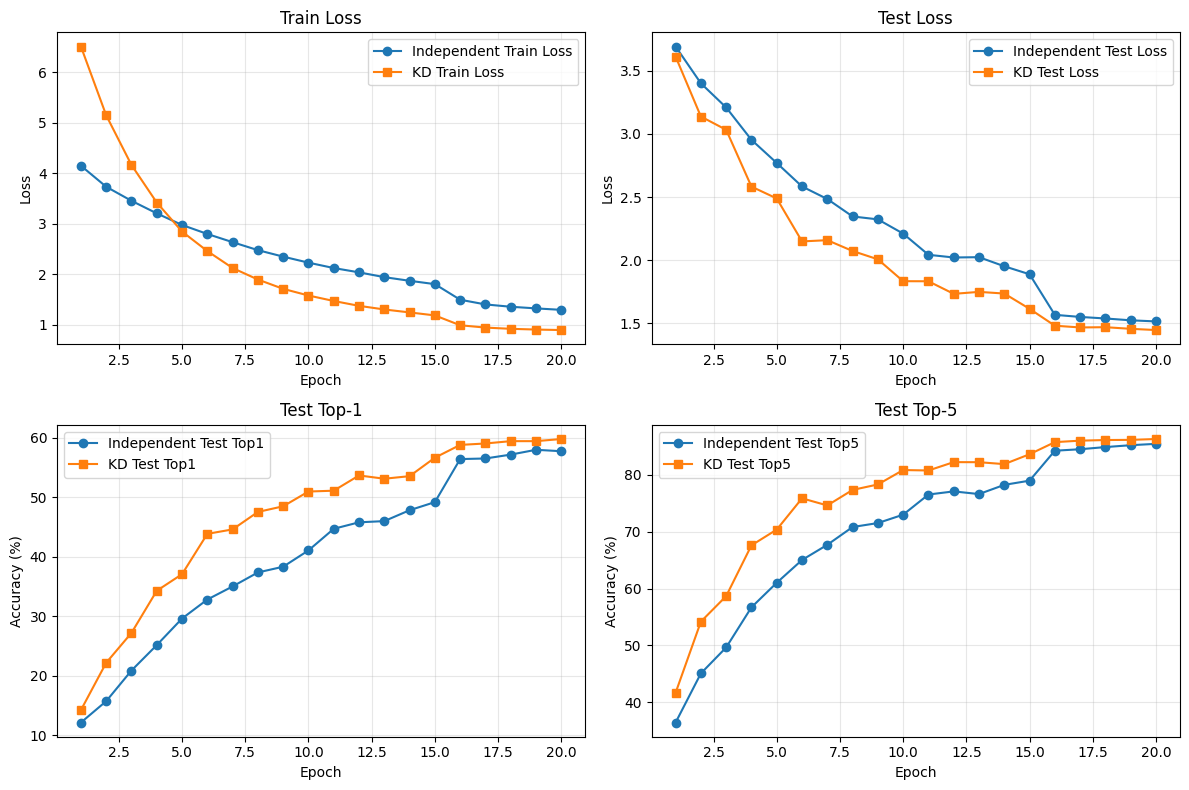


FINAL RESULTS SUMMARY
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Independent student:
  Train Top1: 62.64%  Train Top5: 89.08%
  Test  Top1: 57.73%  Test  Top5: 85.46%

Student with KD (T=3, alpha=0.6):
  Train Top1: 64.58%  Train Top5: 89.78%
  Test  Top1: 59.78%  Test  Top5: 86.31%
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Improvement (Test Top1): +2.05%
Improvement (Test Top5): +0.85%
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++


In [44]:

if __name__ == "__main__":
    main()


##  Discussion: How does Knowledge Distillation affect performance relative to independent student training? Does the student’s convergence behavior during training differ?

### kD with alpha = 0.6, and T = 3.0 sign enhanced the student's gen capability. the distilled vgg stud_model acheived 59.78% top-1 & 86.31% top-5 test accuracy.
### outperforming independent trained student. the improvement is meaningfull gievn teh modest capacity gap b/w vgg_teacher and vgg_stud demonstrate that kd tranfers dark knowledge. 
### the distilled stud exhibit faster & more stable convergence compared to indep training model.

In [9]:
'''
import zipfile  
import os  
from IPython.display import FileLink, display  

# List of model files to download (add more if needed)  
model_files = [  
    'vgg16_teacher_cifar100.pth',  
    'vgg11_independent_cifar100.pth',  
    'vgg11_kd_cifar100.pth',  
    'training_curves.png'  # Optional: include the plot if needed  
]  

# Create a zip file containing the models  
zip_filename = 'task1_models.zip'  
with zipfile.ZipFile(zip_filename, 'w') as zipf:  
    for file in model_files:  
        if os.path.exists(file):  
            zipf.write(file)  
        else:  
            print(f"Warning: {file} not found, skipping.")  

# Display a clickable download link (run this in the notebook)  
if os.path.exists(zip_filename):  
    display(FileLink(zip_filename))  
else:  
    print("No files were zipped.")
'''

/kaggle/working/task1_models.zip

# task 2

In [49]:

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100


In [50]:

# ============================================================================
# CONFIGURATION
# ============================================================================

class Config:
    """Configuration for Task 2 analysis."""
    MAX_TRAIN_SAMPLES = 5000  # Number of train samples to analyze
    MAX_TEST_SAMPLES = 2000   # Number of test samples to analyze
    BATCH_SIZE = 128
    DATA_DIR = './data'
    
    # Model paths (from Task 1)
    TEACHER_PATH = 'vgg16_teacher_cifar100.pth'
    STUDENT_KD_PATH = 'vgg11_kd_cifar100.pth'
    STUDENT_IND_PATH = 'vgg11_independent_cifar100.pth'


In [ ]:

# ============================================================================
# UTILITY FUNCTIONS
# ============================================================================

def standardize_logits(logits):
   
    mean = logits.mean(dim=-1, keepdim=True)
    std = logits.std(dim=-1, keepdim=True)
    return (logits - mean) / (std + 1e-8)

def compute_kl_divergence(teacher_logits, student_logits, temperature=1.0, standardize=False):
   
    if standardize:
        teacher_logits = standardize_logits(teacher_logits)
        student_logits = standardize_logits(student_logits)
    
    teacher_probs = F.softmax(teacher_logits / temperature, dim=-1)
    student_log_probs = F.log_softmax(student_logits / temperature, dim=-1)
    
    kl_div = F.kl_div(student_log_probs, teacher_probs, reduction='batchmean')
    return kl_div.item()

def get_prediction(logits):
   
    return torch.argmax(logits, dim=-1).item()

def compute_rank_correlation(logits1, logits2):
   
    l1 = logits1.detach().cpu().numpy().flatten()
    l2 = logits2.detach().cpu().numpy().flatten()
    
    spearman = spearmanr(l1, l2)[0]
    kendall = kendalltau(l1, l2)[0]
    
    return spearman, kendall

def get_vgg_model(model_type='vgg11', num_classes=100):
    """Get VGG model adapted for CIFAR-100."""
    if model_type == 'vgg11':
        model = vgg11_bn(pretrained=False)
    elif model_type == 'vgg16':
        model = vgg16_bn(pretrained=False)
    else:
        raise ValueError(f"Unknown model type: {model_type}")
    
    model.classifier[6] = nn.Linear(4096, num_classes)
    return model

def load_cifar100_data(batch_size=128):
    """Load CIFAR-100 test data."""
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5071, 0.4867, 0.4408],
                           std=[0.2675, 0.2565, 0.2761])
    ])
    
    trainset = torchvision.datasets.CIFAR100(root=Config.DATA_DIR, train=True,
                                             download=True, transform=transform)
    testset = torchvision.datasets.CIFAR100(root=Config.DATA_DIR, train=False,
                                            download=True, transform=transform)
    
    trainloader = DataLoader(trainset, batch_size=batch_size, shuffle=False,
                            num_workers=2, pin_memory=True)
    testloader = DataLoader(testset, batch_size=batch_size, shuffle=False,
                           num_workers=2, pin_memory=True)
    
    return trainloader, testloader



In [ ]:

# ============================================================================
# TASK 2.1: TOY EXAMPLE - 4-CLASS (Reproducing Sun et al.)
# ============================================================================

def toy_example_4class():
  
    print("\n" + "-"*80)
    print("TASK 2.1: TOY EXAMPLE=4-CLASS CASE")
    print("-"*80)
    
    # Define logits (as in Sun et al. paper)
    teacher = torch.tensor([[4.0, 3.0, 2.0, 1.0]])
    student1 = torch.tensor([[3.9, 3.1, 2.1, 0.9]])  # Correct rank, good match
    student2 = torch.tensor([[10.0, 9.0, 8.0, 11.0]])  # Wrong rank, bad match
    
    print("\nLogits:")
    print(f"Teacher:   {teacher.numpy().flatten()}")
    print(f"Student 1: {student1.numpy().flatten()}")
    print(f"Student 2: {student2.numpy().flatten()}")
    
    # Predictions
    teacher_pred = get_prediction(teacher)
    student1_pred = get_prediction(student1)
    student2_pred = get_prediction(student2)
    
    print(f"\nPredictions:")
    print(f"Teacher:   Class {teacher_pred}")
    print(f"Student 1: Class {student1_pred} {'✓' if student1_pred == teacher_pred else '✗'}")
    print(f"Student 2: Class {student2_pred} {'✓' if student2_pred == teacher_pred else '✗'}")
    
    # Compute KL divergence WITHOUT standardization
    kl1_no_std = compute_kl_divergence(teacher, student1, temperature=1.0, standardize=False)
    kl2_no_std = compute_kl_divergence(teacher, student2, temperature=1.0, standardize=False)
    
    print(f"\n+++ WITHOUT Logit Standardization +++")
    print(f"KL(Teacher || Student1): {kl1_no_std:.6f}")
    print(f"KL(Teacher || Student2): {kl2_no_std:.6f}")
    print(f"Lower KL: Student {'1' if kl1_no_std < kl2_no_std else '2'}")
    print(f"Correct prediction: Student {'1' if student1_pred == teacher_pred else '2'}")
    
    if kl2_no_std < kl1_no_std:
        print("\nRANK MISMATCH DETECTED!")
        print("Student2 has lower KL but WRONG prediction!")
        print("This demonstrates the magnitude-ranking inconsistency.")
    
    # Compute KL divergence WITH standardization
    kl1_std = compute_kl_divergence(teacher, student1, temperature=1.0, standardize=True)
    kl2_std = compute_kl_divergence(teacher, student2, temperature=1.0, standardize=True)
    
    print(f"\n--- WITH Logit Standardization ---")
    print(f"KL(Teacher || Student1): {kl1_std:.6f}")
    print(f"KL(Teacher || Student2): {kl2_std:.6f}")
    print(f"Lower KL: Student {'1' if kl1_std < kl2_std else '2'}")
    print(f"Correct prediction: Student {'1' if student1_pred == teacher_pred else '2'}")
    
    if kl1_std < kl2_std:
        print("\nSTANDARDIZATION FIXES THE ISSUE!")
        print("Student1 has lower KL divergence.")
    
    # Rank correlations
    spearman1, kendall1 = compute_rank_correlation(teacher, student1)
    spearman2, kendall2 = compute_rank_correlation(teacher, student2)
    
    print(f"\nRank Correlations:")
    print(f"Student1 - Spearman: {spearman1:.4f}, Kendall: {kendall1:.4f}")
    print(f"Student2 - Spearman: {spearman2:.4f}, Kendall: {kendall2:.4f}")
    
    # Visualization
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    
    class_names = ['Class 0', 'Class 1', 'Class 2', 'Class 3']
    x = np.arange(4)
    width = 0.25
    
    # Row 1: Original logits and probabilities
    axes[0, 0].bar(x - width, teacher.numpy().flatten(), width, label='Teacher', alpha=0.8)
    axes[0, 0].bar(x, student1.numpy().flatten(), width, label='Student 1', alpha=0.8)
    axes[0, 0].bar(x + width, student2.numpy().flatten(), width, label='Student 2', alpha=0.8)
    axes[0, 0].set_xlabel('Class')
    axes[0, 0].set_ylabel('Logit Value')
    axes[0, 0].set_title('Original Logits')
    axes[0, 0].set_xticks(x)
    axes[0, 0].set_xticklabels(class_names)
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # Original probabilities
    teacher_probs = F.softmax(teacher, dim=-1).numpy().flatten()
    student1_probs = F.softmax(student1, dim=-1).numpy().flatten()
    student2_probs = F.softmax(student2, dim=-1).numpy().flatten()
    
    axes[0, 1].bar(x - width, teacher_probs, width, label='Teacher', alpha=0.8)
    axes[0, 1].bar(x, student1_probs, width, label='Student 1', alpha=0.8)
    axes[0, 1].bar(x + width, student2_probs, width, label='Student 2', alpha=0.8)
    axes[0, 1].set_xlabel('Class')
    axes[0, 1].set_ylabel('Probability')
    axes[0, 1].set_title('Softmax Probabilities (No Standardization)')
    axes[0, 1].set_xticks(x)
    axes[0, 1].set_xticklabels(class_names)
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    # KL divergence comparison (no standardization)
    kl_values_no_std = [kl1_no_std, kl2_no_std]
    colors_no_std = ['green' if student1_pred == teacher_pred else 'red',
                     'green' if student2_pred == teacher_pred else 'red']
    axes[0, 2].bar(['Student 1', 'Student 2'], kl_values_no_std, color=colors_no_std, alpha=0.7)
    axes[0, 2].set_ylabel('KL Divergence')
    axes[0, 2].set_title('KL Divergence (No Standardization)')
    axes[0, 2].grid(True, alpha=0.3)
    for i, v in enumerate(kl_values_no_std):
        axes[0, 2].text(i, v + 0.001, f'{v:.4f}', ha='center', va='bottom')
    
    # Row 2: Standardized logits and probabilities
    teacher_std = standardize_logits(teacher)
    student1_std = standardize_logits(student1)
    student2_std = standardize_logits(student2)
    
    axes[1, 0].bar(x - width, teacher_std.numpy().flatten(), width, label='Teacher', alpha=0.8)
    axes[1, 0].bar(x, student1_std.numpy().flatten(), width, label='Student 1', alpha=0.8)
    axes[1, 0].bar(x + width, student2_std.numpy().flatten(), width, label='Student 2', alpha=0.8)
    axes[1, 0].set_xlabel('Class')
    axes[1, 0].set_ylabel('Standardized Logit Value')
    axes[1, 0].set_title('Standardized Logits')
    axes[1, 0].set_xticks(x)
    axes[1, 0].set_xticklabels(class_names)
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    
    # Standardized probabilities
    teacher_probs_std = F.softmax(teacher_std, dim=-1).numpy().flatten()
    student1_probs_std = F.softmax(student1_std, dim=-1).numpy().flatten()
    student2_probs_std = F.softmax(student2_std, dim=-1).numpy().flatten()
    
    axes[1, 1].bar(x - width, teacher_probs_std, width, label='Teacher', alpha=0.8)
    axes[1, 1].bar(x, student1_probs_std, width, label='Student 1', alpha=0.8)
    axes[1, 1].bar(x + width, student2_probs_std, width, label='Student 2', alpha=0.8)
    axes[1, 1].set_xlabel('Class')
    axes[1, 1].set_ylabel('Probability')
    axes[1, 1].set_title('Softmax Probabilities (With Standardization)')
    axes[1, 1].set_xticks(x)
    axes[1, 1].set_xticklabels(class_names)
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)
    
    # KL divergence comparison (with standardization)
    kl_values_std = [kl1_std, kl2_std]
    axes[1, 2].bar(['Student 1', 'Student 2'], kl_values_std, color=colors_no_std, alpha=0.7)
    axes[1, 2].set_ylabel('KL Divergence')
    axes[1, 2].set_title('KL Divergence (With Standardization)')
    axes[1, 2].grid(True, alpha=0.3)
    for i, v in enumerate(kl_values_std):
        axes[1, 2].text(i, v + 0.001, f'{v:.4f}', ha='center', va='bottom')
    
    plt.tight_layout()
    plt.savefig('task2_toy_4class_analysis.png', dpi=300, bbox_inches='tight')
    print(f"\nVisualization saved to 'task2_toy_4class_analysis.png'")
    plt.show()
    
    return {
        'teacher': teacher,
        'student1': student1,
        'student2': student2,
        'kl1_no_std': kl1_no_std,
        'kl2_no_std': kl2_no_std,
        'kl1_std': kl1_std,
        'kl2_std': kl2_std
    }




In [ ]:

# ============================================================================
# TASK 2.2: TOY EXAMPLE - 10-CLASS
# ============================================================================

def toy_example_10class():
    
    print("\n" + "="*80)
    print("TASK 2.2: TOY EXAMPLE-10 CLASS CASE")
    print("="*80)
    
    # Create synthetic logits
    teacher = torch.tensor([[5.0, 4.0, 3.5, 3.0, 2.5, 2.0, 1.5, 1.0, 0.5, 0.0]])
    student1 = torch.tensor([[4.8, 3.9, 3.4, 2.9, 2.4, 1.9, 1.4, 0.9, 0.4, -0.1]])
    student2 = torch.tensor([[12.0, 11.5, 11.0, 10.5, 10.0, 9.5, 9.0, 8.5, 8.0, 13.0]])
    
    print("\nLogits showing 10 classes:")
    print(f"Teacher:   {teacher.numpy().flatten()}")
    print(f"Student 1: {student1.numpy().flatten()}")
    print(f"Student 2: {student2.numpy().flatten()}")
    
    # Predictions
    teacher_pred = get_prediction(teacher)
    student1_pred = get_prediction(student1)
    student2_pred = get_prediction(student2)
    
    print(f"\nPredictions:")
    print(f"Teacher:   Class {teacher_pred}")
    print(f"Student 1: Class {student1_pred} {'✓' if student1_pred == teacher_pred else '✗'}")
    print(f"Student 2: Class {student2_pred} {'✓' if student2_pred == teacher_pred else '✗'}")
    
    # Compute KL divergences
    kl1_no_std = compute_kl_divergence(teacher, student1, temperature=1.0, standardize=False)
    kl2_no_std = compute_kl_divergence(teacher, student2, temperature=1.0, standardize=False)
    
    print(f"\n+++ WITHOUT Logit Standardization +++")
    print(f"KL(Teacher || Student1): {kl1_no_std:.6f}")
    print(f"KL(Teacher || Student2): {kl2_no_std:.6f}")
    print(f"Lower KL: Student {'1' if kl1_no_std < kl2_no_std else '2'}")
    
    if kl2_no_std < kl1_no_std and student2_pred != teacher_pred:
        print("\nRANK MISMATCH DETECTED!")
        print("Student2 has lower KL but WRONG prediction!")
    
    # Compute KL divergence WITH standardization
    kl1_std = compute_kl_divergence(teacher, student1, temperature=1.0, standardize=True)
    kl2_std = compute_kl_divergence(teacher, student2, temperature=1.0, standardize=True)
    
    print(f"\n=== WITH Logit Standardization ===")
    print(f"KL(Teacher || Student1): {kl1_std:.6f}")
    print(f"KL(Teacher || Student2): {kl2_std:.6f}")
    print(f"Lower KL: Student {'1' if kl1_std < kl2_std else '2'}")
    
    if kl1_std < kl2_std:
        print("\nSTANDARDIZATION FIXES THE ISSUE!")
        print("Student1 has lower KL divergence.")
    
    # Rank correlations
    spearman1, kendall1 = compute_rank_correlation(teacher, student1)
    spearman2, kendall2 = compute_rank_correlation(teacher, student2)
    
    print(f"\nRank Correlations:")
    print(f"Student1 - Spearman: {spearman1:.4f}, Kendall: {kendall1:.4f}")
    print(f"Student2 - Spearman: {spearman2:.4f}, Kendall: {kendall2:.4f}")
    
    # Visualization
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    class_names = [f'C{i}' for i in range(10)]
    x = np.arange(10)
    width = 0.25
    
    # Original logits
    axes[0, 0].bar(x - width, teacher.numpy().flatten(), width, label='Teacher', alpha=0.8)
    axes[0, 0].bar(x, student1.numpy().flatten(), width, label='Student 1', alpha=0.8)
    axes[0, 0].bar(x + width, student2.numpy().flatten(), width, label='Student 2', alpha=0.8)
    axes[0, 0].set_xlabel('Class')
    axes[0, 0].set_ylabel('Logit Value')
    axes[0, 0].set_title('Original Logits (10 Classes)')
    axes[0, 0].set_xticks(x)
    axes[0, 0].set_xticklabels(class_names, rotation=45)
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # KL divergence (no standardization)
    kl_values_no_std = [kl1_no_std, kl2_no_std]
    colors = ['green' if student1_pred == teacher_pred else 'red',
              'green' if student2_pred == teacher_pred else 'red']
    axes[0, 1].bar(['Student 1', 'Student 2'], kl_values_no_std, color=colors, alpha=0.7)
    axes[0, 1].set_ylabel('KL Divergence')
    axes[0, 1].set_title('KL Divergence (No Standardization)')
    axes[0, 1].grid(True, alpha=0.3)
    for i, v in enumerate(kl_values_no_std):
        axes[0, 1].text(i, v + 0.001, f'{v:.4f}', ha='center', va='bottom')
    
    # Standardized logits
    teacher_std = standardize_logits(teacher)
    student1_std = standardize_logits(student1)
    student2_std = standardize_logits(student2)
    
    axes[1, 0].bar(x - width, teacher_std.numpy().flatten(), width, label='Teacher', alpha=0.8)
    axes[1, 0].bar(x, student1_std.numpy().flatten(), width, label='Student 1', alpha=0.8)
    axes[1, 0].bar(x + width, student2_std.numpy().flatten(), width, label='Student 2', alpha=0.8)
    axes[1, 0].set_xlabel('Class')
    axes[1, 0].set_ylabel('Standardized Logit Value')
    axes[1, 0].set_title('Standardized Logits')
    axes[1, 0].set_xticks(x)
    axes[1, 0].set_xticklabels(class_names, rotation=45)
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    
    # KL divergence (with standardization)
    kl_values_std = [kl1_std, kl2_std]
    axes[1, 1].bar(['Student 1', 'Student 2'], kl_values_std, color=colors, alpha=0.7)
    axes[1, 1].set_ylabel('KL Divergence')
    axes[1, 1].set_title('KL Divergence (With Standardization)')
    axes[1, 1].grid(True, alpha=0.3)
    for i, v in enumerate(kl_values_std):
        axes[1, 1].text(i, v + 0.001, f'{v:.4f}', ha='center', va='bottom')
    
    plt.tight_layout()
    plt.savefig('task2_toy_10class_analysis.png', dpi=300, bbox_inches='tight')
    print(f"\nVisualization saved to 'task2_toy_10class_analysis.png'")
    plt.show()
    
    return {
        'teacher': teacher,
        'student1': student1,
        'student2': student2,
        'kl1_no_std': kl1_no_std,
        'kl2_no_std': kl2_no_std,
        'kl1_std': kl1_std,
        'kl2_std': kl2_std
    }


In [ ]:

# ============================================================================
# TASK 2.3: REAL CIFAR-100 ANALYSIS
# ============================================================================

def analyze_cifar100_logits(teacher_model, student_kd_model, student_ind_model, 
                            dataloader, dataset_name='train', max_samples=5000):
   
    teacher_model.eval()
    student_kd_model.eval()
    student_ind_model.eval()
    
    mismatch_cases = []
    all_cases = []
    
    sample_idx = 0
    
    with torch.no_grad():
        for batch_idx, (inputs, targets) in enumerate(tqdm(dataloader, desc=f'Analyzing {dataset_name} set')):
            if sample_idx >= max_samples:
                break
            
            inputs, targets = inputs.to(device), targets.to(device)
            
            # Get logits from all models
            teacher_logits = teacher_model(inputs)
            student_kd_logits = student_kd_model(inputs)
            student_ind_logits = student_ind_model(inputs)
            
            # Process each sample in batch
            for i in range(inputs.size(0)):
                if sample_idx >= max_samples:
                    break
                
                t_logit = teacher_logits[i:i+1]
                skd_logit = student_kd_logits[i:i+1]
                sind_logit = student_ind_logits[i:i+1]
                target = targets[i].item()
                
                # Predictions
                t_pred = torch.argmax(t_logit, dim=1).item()
                skd_pred = torch.argmax(skd_logit, dim=1).item()
                sind_pred = torch.argmax(sind_logit, dim=1).item()
                
                # KL divergences (no standardization)
                kl_kd = compute_kl_divergence(t_logit, skd_logit, temperature=1.0, standardize=False)
                kl_ind = compute_kl_divergence(t_logit, sind_logit, temperature=1.0, standardize=False)
                
                # KL divergences (with standardization)
                kl_kd_std = compute_kl_divergence(t_logit, skd_logit, temperature=1.0, standardize=True)
                kl_ind_std = compute_kl_divergence(t_logit, sind_logit, temperature=1.0, standardize=True)
                
                # Rank correlations
                spearman_kd, kendall_kd = compute_rank_correlation(t_logit, skd_logit)
                spearman_ind, kendall_ind = compute_rank_correlation(t_logit, sind_logit)
                
                case_info = {
                    'sample_idx': sample_idx,
                    'true_label': target,
                    'teacher_pred': t_pred,
                    'kd_student_pred': skd_pred,
                    'ind_student_pred': sind_pred,
                    'kl_kd': kl_kd,
                    'kl_ind': kl_ind,
                    'kl_kd_std': kl_kd_std,
                    'kl_ind_std': kl_ind_std,
                    'spearman_kd': spearman_kd,
                    'spearman_ind': spearman_ind,
                    'kendall_kd': kendall_kd,
                    'kendall_ind': kendall_ind,
                    'teacher_logit': t_logit.cpu(),
                    'kd_logit': skd_logit.cpu(),
                    'ind_logit': sind_logit.cpu()
                }
                
                all_cases.append(case_info)
               
                if (kl_kd < kl_ind and 
                    skd_pred != t_pred and 
                    sind_pred == t_pred):
                    
                    mismatch_cases.append(case_info)
                
                sample_idx += 1
    
    print(f"\n{dataset_name.upper()} SET ANALYSIS:")
    print(f"Total samples analyzed: {len(all_cases)}")
    print(f"Rank mismatch cases found: {len(mismatch_cases)}")
    print(f"Frequency: {len(mismatch_cases)/len(all_cases)*100:.2f}%")
    
    return mismatch_cases, all_cases


In [ ]:

def create_summary_table(mismatch_cases, all_cases, dataset_name):
  
    if len(mismatch_cases) == 0:
        print(f"\nNo mismatch cases found in {dataset_name} set.")
        return None
    
    print(f"\n{dataset_name.upper()} SET - SAMPLE MISMATCH CASES:")
    print("+"*120)
    
    #  first few cases
    df_data = []
    for i, case in enumerate(mismatch_cases[:10]):  #  first 10
        df_data.append({
            'Sample': case['sample_idx'],
            'True Label': case['true_label'],
            'Teacher Pred': case['teacher_pred'],
            'KD Pred': case['kd_student_pred'],
            'Ind Pred': case['ind_student_pred'],
            'KL_KD': f"{case['kl_kd']:.4f}",
            'KL_Ind': f"{case['kl_ind']:.4f}",
            'KL_KD_std': f"{case['kl_kd_std']:.4f}",
            'KL_Ind_std': f"{case['kl_ind_std']:.4f}",
            'Spearman_KD': f"{case['spearman_kd']:.3f}",
            'Spearman_Ind': f"{case['spearman_ind']:.3f}"
        })
    
    df = pd.DataFrame(df_data)
    print(df.to_string(index=False))
    print("+"*120)
    
    # Summary statistics
    avg_kl_kd = np.mean([c['kl_kd'] for c in mismatch_cases])
    avg_kl_ind = np.mean([c['kl_ind'] for c in mismatch_cases])
    avg_kl_kd_std = np.mean([c['kl_kd_std'] for c in mismatch_cases])
    avg_kl_ind_std = np.mean([c['kl_ind_std'] for c in mismatch_cases])
    
    print(f"\nMISMATCH CASES STATISTICS:")
    print(f"Average KL (KD student):          {avg_kl_kd:.4f}")
    print(f"Average KL (Ind student):         {avg_kl_ind:.4f}")
    print(f"Average KL_std (KD student):      {avg_kl_kd_std:.4f}")
    print(f"Average KL_std (Ind student):     {avg_kl_ind_std:.4f}")
    
    # Check if standardization helps
    cases_fixed = sum(1 for c in mismatch_cases if c['kl_ind_std'] < c['kl_kd_std'])
    print(f"\nCases where standardization fixes the ordering: {cases_fixed}/{len(mismatch_cases)} ({cases_fixed/len(mismatch_cases)*100:.1f}%)")
    
    return df

def visualize_mismatch_cases(mismatch_cases, dataset_name, num_cases=3):
    """Visualize specific mismatch cases."""
    if len(mismatch_cases) == 0:
        print("No mismatch cases to visualize.")
        return
    
    num_cases = min(num_cases, len(mismatch_cases))
    fig, axes = plt.subplots(num_cases, 3, figsize=(15, 4*num_cases))
    
    if num_cases == 1:
        axes = axes.reshape(1, -1)
    
    for idx in range(num_cases):
        case = mismatch_cases[idx]
        
        teacher_logit = case['teacher_logit'].numpy().flatten()
        kd_logit = case['kd_logit'].numpy().flatten()
        ind_logit = case['ind_logit'].numpy().flatten()
        
        # Standardized versions
        teacher_std = standardize_logits(case['teacher_logit']).numpy().flatten()
        kd_std = standardize_logits(case['kd_logit']).numpy().flatten()
        ind_std = standardize_logits(case['ind_logit']).numpy().flatten()
        
        x = np.arange(len(teacher_logit))
        
        # Plot 1: Original logits
        axes[idx, 0].plot(x, teacher_logit, 'o-', label='Teacher', linewidth=2, markersize=3, alpha=0.7)
        axes[idx, 0].plot(x, kd_logit, 's-', label='KD Student', linewidth=2, markersize=3, alpha=0.7)
        axes[idx, 0].plot(x, ind_logit, '^-', label='Ind Student', linewidth=2, markersize=3, alpha=0.7)
        axes[idx, 0].axvline(case['teacher_pred'], color='green', linestyle='--', alpha=0.5, label='Teacher pred')
        axes[idx, 0].axvline(case['kd_student_pred'], color='red', linestyle='--', alpha=0.5, label='KD pred (wrong)')
        axes[idx, 0].axvline(case['ind_student_pred'], color='blue', linestyle='--', alpha=0.5, label='Ind pred (correct)')
        axes[idx, 0].set_xlabel('Class Index')
        axes[idx, 0].set_ylabel('Logit Value')
        axes[idx, 0].set_title(f'Sample {case["sample_idx"]} - Original Logits\nKL_KD={case["kl_kd"]:.3f}, KL_Ind={case["kl_ind"]:.3f}')
        axes[idx, 0].legend(fontsize=8)
        axes[idx, 0].grid(True, alpha=0.3)
        
        # Plot 2: Standardized logits
        axes[idx, 1].plot(x, teacher_std, 'o-', label='Teacher', linewidth=2, markersize=3, alpha=0.7)
        axes[idx, 1].plot(x, kd_std, 's-', label='KD Student', linewidth=2, markersize=3, alpha=0.7)
        axes[idx, 1].plot(x, ind_std, '^-', label='Ind Student', linewidth=2, markersize=3, alpha=0.7)
        axes[idx, 1].axvline(case['teacher_pred'], color='green', linestyle='--', alpha=0.5)
        axes[idx, 1].axvline(case['kd_student_pred'], color='red', linestyle='--', alpha=0.5)
        axes[idx, 1].axvline(case['ind_student_pred'], color='blue', linestyle='--', alpha=0.5)
        axes[idx, 1].set_xlabel('Class Index')
        axes[idx, 1].set_ylabel('Standardized Logit Value')
        axes[idx, 1].set_title(f'Standardized Logits\nKL_KD_std={case["kl_kd_std"]:.3f}, KL_Ind_std={case["kl_ind_std"]:.3f}')
        axes[idx, 1].legend(fontsize=8)
        axes[idx, 1].grid(True, alpha=0.3)
        
        # Plot 3: KL divergence comparison
        kl_comparison = {
            'KD\n(No Std)': case['kl_kd'],
            'Ind\n(No Std)': case['kl_ind'],
            'KD\n(Std)': case['kl_kd_std'],
            'Ind\n(Std)': case['kl_ind_std']
        }
        colors = ['red', 'blue', 'lightcoral', 'lightblue']
        bars = axes[idx, 2].bar(kl_comparison.keys(), kl_comparison.values(), color=colors, alpha=0.7)
        axes[idx, 2].set_ylabel('KL Divergence')
        axes[idx, 2].set_title('KL Divergence Comparison')
        axes[idx, 2].grid(True, alpha=0.3, axis='y')
        
        # Add value labels on bars
        for bar in bars:
            height = bar.get_height()
            axes[idx, 2].text(bar.get_x() + bar.get_width()/2., height,
                            f'{height:.3f}', ha='center', va='bottom', fontsize=9)
    
    plt.tight_layout()
    plt.savefig(f'task2_cifar100_mismatch_cases_{dataset_name}.png', dpi=300, bbox_inches='tight')
    print(f"\nVisualization saved to 'task2_cifar100_mismatch_cases_{dataset_name}.png'")
    plt.show()

def create_comprehensive_summary(train_mismatch, train_all, test_mismatch, test_all):
    
    print("TASK 2: COMPREHENSIVE SUMMARY TABLE")
    print("+"*80)
    
    summary_data = []
    
    # Overall statistics
    for dataset_name, mismatch, all_cases in [('Train', train_mismatch, train_all), 
                                               ('Test', test_mismatch, test_all)]:
        if len(all_cases) > 0:
            # Calculate various metrics
            total = len(all_cases)
            mismatch_count = len(mismatch)
            mismatch_freq = mismatch_count / total * 100
            
            # Average KL divergences
            avg_kl_kd = np.mean([c['kl_kd'] for c in all_cases])
            avg_kl_ind = np.mean([c['kl_ind'] for c in all_cases])
            avg_kl_kd_std = np.mean([c['kl_kd_std'] for c in all_cases])
            avg_kl_ind_std = np.mean([c['kl_ind_std'] for c in all_cases])
            
            # Prediction accuracies
            kd_correct = sum(1 for c in all_cases if c['kd_student_pred'] == c['teacher_pred'])
            ind_correct = sum(1 for c in all_cases if c['ind_student_pred'] == c['teacher_pred'])
            
            kd_acc = kd_correct / total * 100
            ind_acc = ind_correct / total * 100
            
            # Average rank correlations
            avg_spearman_kd = np.mean([c['spearman_kd'] for c in all_cases])
            avg_spearman_ind = np.mean([c['spearman_ind'] for c in all_cases])
            
            # Fixed by standardization
            fixed_by_std = sum(1 for c in mismatch if c['kl_ind_std'] < c['kl_kd_std']) if mismatch else 0
            fix_rate = fixed_by_std / len(mismatch) * 100 if mismatch else 0
            
            summary_data.append({
                'Dataset': dataset_name,
                'Total Samples': total,
                'Mismatch Cases': mismatch_count,
                'Mismatch %': f'{mismatch_freq:.2f}%',
                'Fixed by Std': f'{fixed_by_std}/{mismatch_count}' if mismatch else 'N/A',
                'Fix Rate %': f'{fix_rate:.1f}%' if mismatch else 'N/A',
                'Avg KL (KD)': f'{avg_kl_kd:.4f}',
                'Avg KL (Ind)': f'{avg_kl_ind:.4f}',
                'Avg KL_std (KD)': f'{avg_kl_kd_std:.4f}',
                'Avg KL_std (Ind)': f'{avg_kl_ind_std:.4f}',
                'KD Pred Acc %': f'{kd_acc:.2f}%',
                'Ind Pred Acc %': f'{ind_acc:.2f}%',
                'Avg Spearman (KD)': f'{avg_spearman_kd:.3f}',
                'Avg Spearman (Ind)': f'{avg_spearman_ind:.3f}'
            })
    
    df_summary = pd.DataFrame(summary_data)
    print("\n" + df_summary.to_string(index=False))
    print("+"*80)
    
    # Save to CSV
    df_summary.to_csv('task2_comprehensive_summary.csv', index=False)
    print("\nComprehensive summary saved to 'task2_comprehensive_summary.csv'")
    
    return df_summary

def plot_overall_statistics(train_all, test_all):
    """Plot overall statistics comparing KD and Independent students."""
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    
    for idx, (dataset_name, all_cases) in enumerate([('Train', train_all), ('Test', test_all)]):
        if len(all_cases) == 0:
            continue
        
        kl_kd = [c['kl_kd'] for c in all_cases]
        kl_ind = [c['kl_ind'] for c in all_cases]
        kl_kd_std = [c['kl_kd_std'] for c in all_cases]
        kl_ind_std = [c['kl_ind_std'] for c in all_cases]
        spearman_kd = [c['spearman_kd'] for c in all_cases]
        spearman_ind = [c['spearman_ind'] for c in all_cases]
        
        # Plot 1: KL divergence distribution (no std)
        axes[idx, 0].hist(kl_kd, bins=50, alpha=0.5, label='KD Student', color='red')
        axes[idx, 0].hist(kl_ind, bins=50, alpha=0.5, label='Ind Student', color='blue')
        axes[idx, 0].axvline(np.mean(kl_kd), color='red', linestyle='--', linewidth=2, label=f'Mean KD: {np.mean(kl_kd):.3f}')
        axes[idx, 0].axvline(np.mean(kl_ind), color='blue', linestyle='--', linewidth=2, label=f'Mean Ind: {np.mean(kl_ind):.3f}')
        axes[idx, 0].set_xlabel('KL Divergence')
        axes[idx, 0].set_ylabel('Frequency')
        axes[idx, 0].set_title(f'{dataset_name} Set - KL Divergence Distribution (No Std)')
        axes[idx, 0].legend()
        axes[idx, 0].grid(True, alpha=0.3)
        
        # Plot 2: KL divergence distribution (with std)
        axes[idx, 1].hist(kl_kd_std, bins=50, alpha=0.5, label='KD Student', color='red')
        axes[idx, 1].hist(kl_ind_std, bins=50, alpha=0.5, label='Ind Student', color='blue')
        axes[idx, 1].axvline(np.mean(kl_kd_std), color='red', linestyle='--', linewidth=2, label=f'Mean KD: {np.mean(kl_kd_std):.3f}')
        axes[idx, 1].axvline(np.mean(kl_ind_std), color='blue', linestyle='--', linewidth=2, label=f'Mean Ind: {np.mean(kl_ind_std):.3f}')
        axes[idx, 1].set_xlabel('KL Divergence (Standardized)')
        axes[idx, 1].set_ylabel('Frequency')
        axes[idx, 1].set_title(f'{dataset_name} Set - KL Divergence Distribution (With Std)')
        axes[idx, 1].legend()
        axes[idx, 1].grid(True, alpha=0.3)
        
        # Plot 3: Rank correlation distribution
        axes[idx, 2].hist(spearman_kd, bins=50, alpha=0.5, label='KD Student', color='red')
        axes[idx, 2].hist(spearman_ind, bins=50, alpha=0.5, label='Ind Student', color='blue')
        axes[idx, 2].axvline(np.mean(spearman_kd), color='red', linestyle='--', linewidth=2, label=f'Mean KD: {np.mean(spearman_kd):.3f}')
        axes[idx, 2].axvline(np.mean(spearman_ind), color='blue', linestyle='--', linewidth=2, label=f'Mean Ind: {np.mean(spearman_ind):.3f}')
        axes[idx, 2].set_xlabel('Spearman Correlation')
        axes[idx, 2].set_ylabel('Frequency')
        axes[idx, 2].set_title(f'{dataset_name} Set - Rank Correlation Distribution')
        axes[idx, 2].legend()
        axes[idx, 2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('task2_overall_statistics.png', dpi=300, bbox_inches='tight')
    print("\nOverall statistics plot saved to 'task2_overall_statistics.png'")
    plt.show()


********************************************************************************
TASK 2: LOGIT STANDARDIZATION IN KNOWLEDGE DISTILLATION
Device: cuda

[Step 1/7] Checking Task 1 models...
All required model files found!

[Step 2/7] Running 4-class toy example...

------------------------------------------------------------
TASK 2.1: TOY EXAMPLE — 4 CLASS CASE
------------------------------------------------------------
Teacher: 0, Student1: 0, Student2: 3


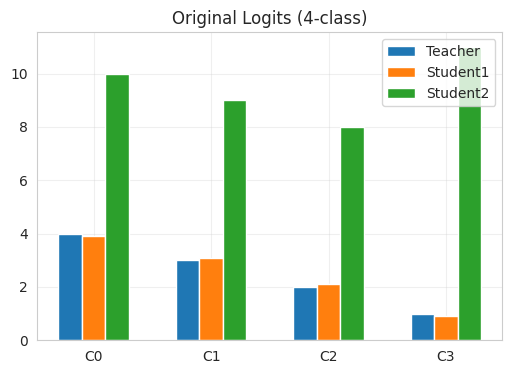

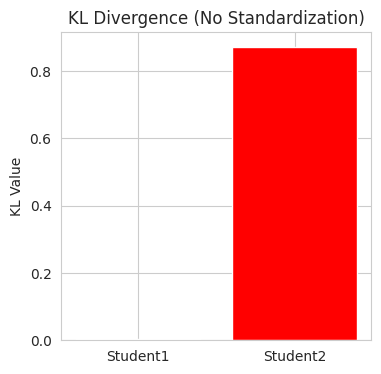

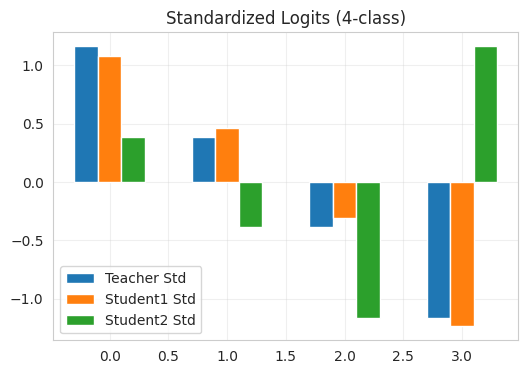


KL (No Std): S1=0.0045, S2=0.8718
KL (Std): S1=0.0030, S2=0.6033
Lower KL (Std): Student1

[Step 3/7] Running 10-class toy example...

TASK 2.2: TOY EXAMPLE-10 CLASS CASE

Logits showing 10 classes:
Teacher:   [5.  4.  3.5 3.  2.5 2.  1.5 1.  0.5 0. ]
Student 1: [ 4.8  3.9  3.4  2.9  2.4  1.9  1.4  0.9  0.4 -0.1]
Student 2: [12.  11.5 11.  10.5 10.   9.5  9.   8.5  8.  13. ]

Predictions:
Teacher:   Class 0
Student 1: Class 0 ✓
Student 2: Class 9 ✗

+++ WITHOUT Logit Standardization +++
KL(Teacher || Student1): 0.001249
KL(Teacher || Student2): 0.740542
Lower KL: Student 1

=== WITH Logit Standardization ===
KL(Teacher || Student1): 0.000280
KL(Teacher || Student2): 0.367916
Lower KL: Student 1

STANDARDIZATION FIXES THE ISSUE!
Student1 (correct prediction) now has lower KL divergence.

Rank Correlations:
Student1 - Spearman: 1.0000, Kendall: 1.0000
Student2 - Spearman: 0.4545, Kendall: 0.6000

Visualization saved to 'task2_toy_10class_analysis.png'


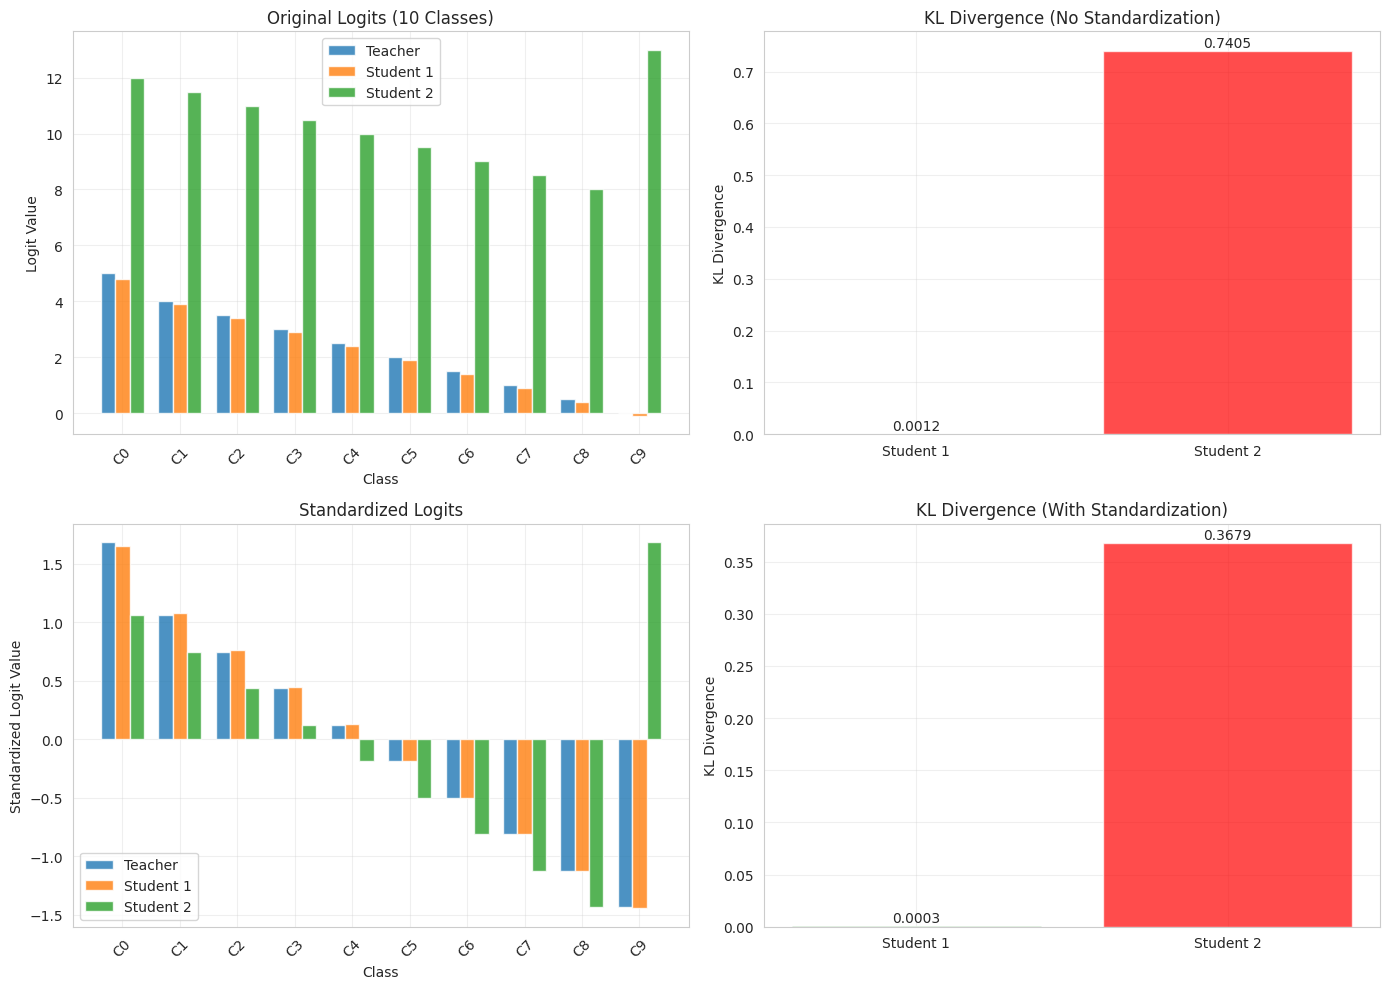


[Step 4/7] Loading CIFAR-100 data...

[Step 5/7] Loading trained models from Task 1...


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


 Models loaded successfully!

[Step 6/7] Analyzing CIFAR-100 logits...


Analyzing train set:  10%|█         | 40/391 [00:15<02:17,  2.55it/s]



TRAIN SET ANALYSIS:
Total samples analyzed: 5000
Rank mismatch cases found: 122
Frequency: 2.44%


Analyzing test set:  20%|██        | 16/79 [00:06<00:24,  2.58it/s]



TEST SET ANALYSIS:
Total samples analyzed: 2000
Rank mismatch cases found: 45
Frequency: 2.25%

TRAIN SET - SAMPLE MISMATCH CASES:
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
 Sample  True Label  Teacher Pred  KD Pred  Ind Pred  KL_KD KL_Ind KL_KD_std KL_Ind_std Spearman_KD Spearman_Ind
     33          65            65       66        65 0.4822 0.9769    0.0676     0.1623       0.960        0.906
     37          11            35       11        35 0.0803 0.0959    0.0091     0.0351       0.981        0.864
    115          33            33       60        33 0.1056 0.5350    0.0221     0.0793       0.976        0.900
    153          27            38       27        38 0.2179 0.2710    0.0339     0.0681       0.967        0.919
    249          40            40       86        40 0.2594 0.3099    0.0294     0.0407       0.976        0.957
    309           7             7       24         7 0.1514 0.2583   

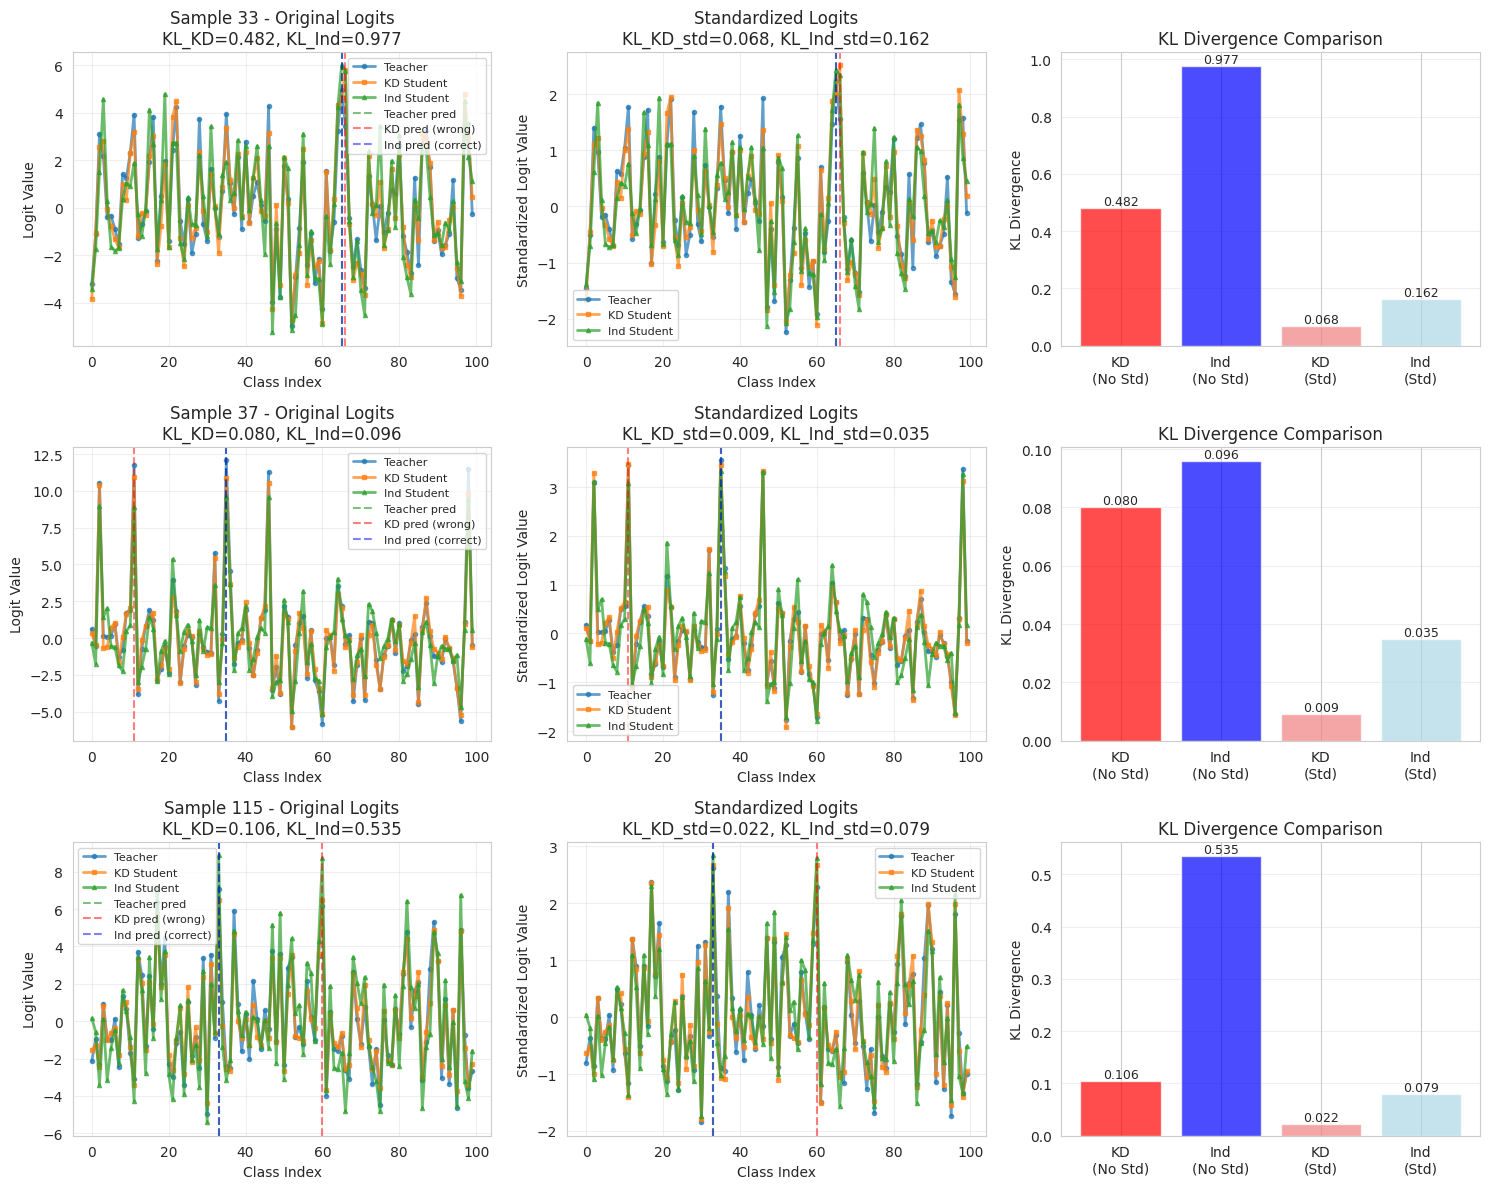


TEST SET - SAMPLE MISMATCH CASES:
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
 Sample  True Label  Teacher Pred  KD Pred  Ind Pred  KL_KD KL_Ind KL_KD_std KL_Ind_std Spearman_KD Spearman_Ind
     74          32            76       49        76 0.4642 0.6697    0.0664     0.1418       0.944        0.879
    171          37            84       25        84 0.2878 0.4017    0.0625     0.0676       0.962        0.942
    227          76            39       76        39 0.3787 0.4727    0.0376     0.0774       0.968        0.884
    290          27            27       32        27 0.4119 0.5560    0.0341     0.0698       0.976        0.914
    408          98            46       98        46 0.0473 0.1017    0.0224     0.0323       0.971        0.942
    427          10            28       61        28 0.2786 0.3342    0.0237     0.0629       0.967        0.905
    448          55            50       29        50 

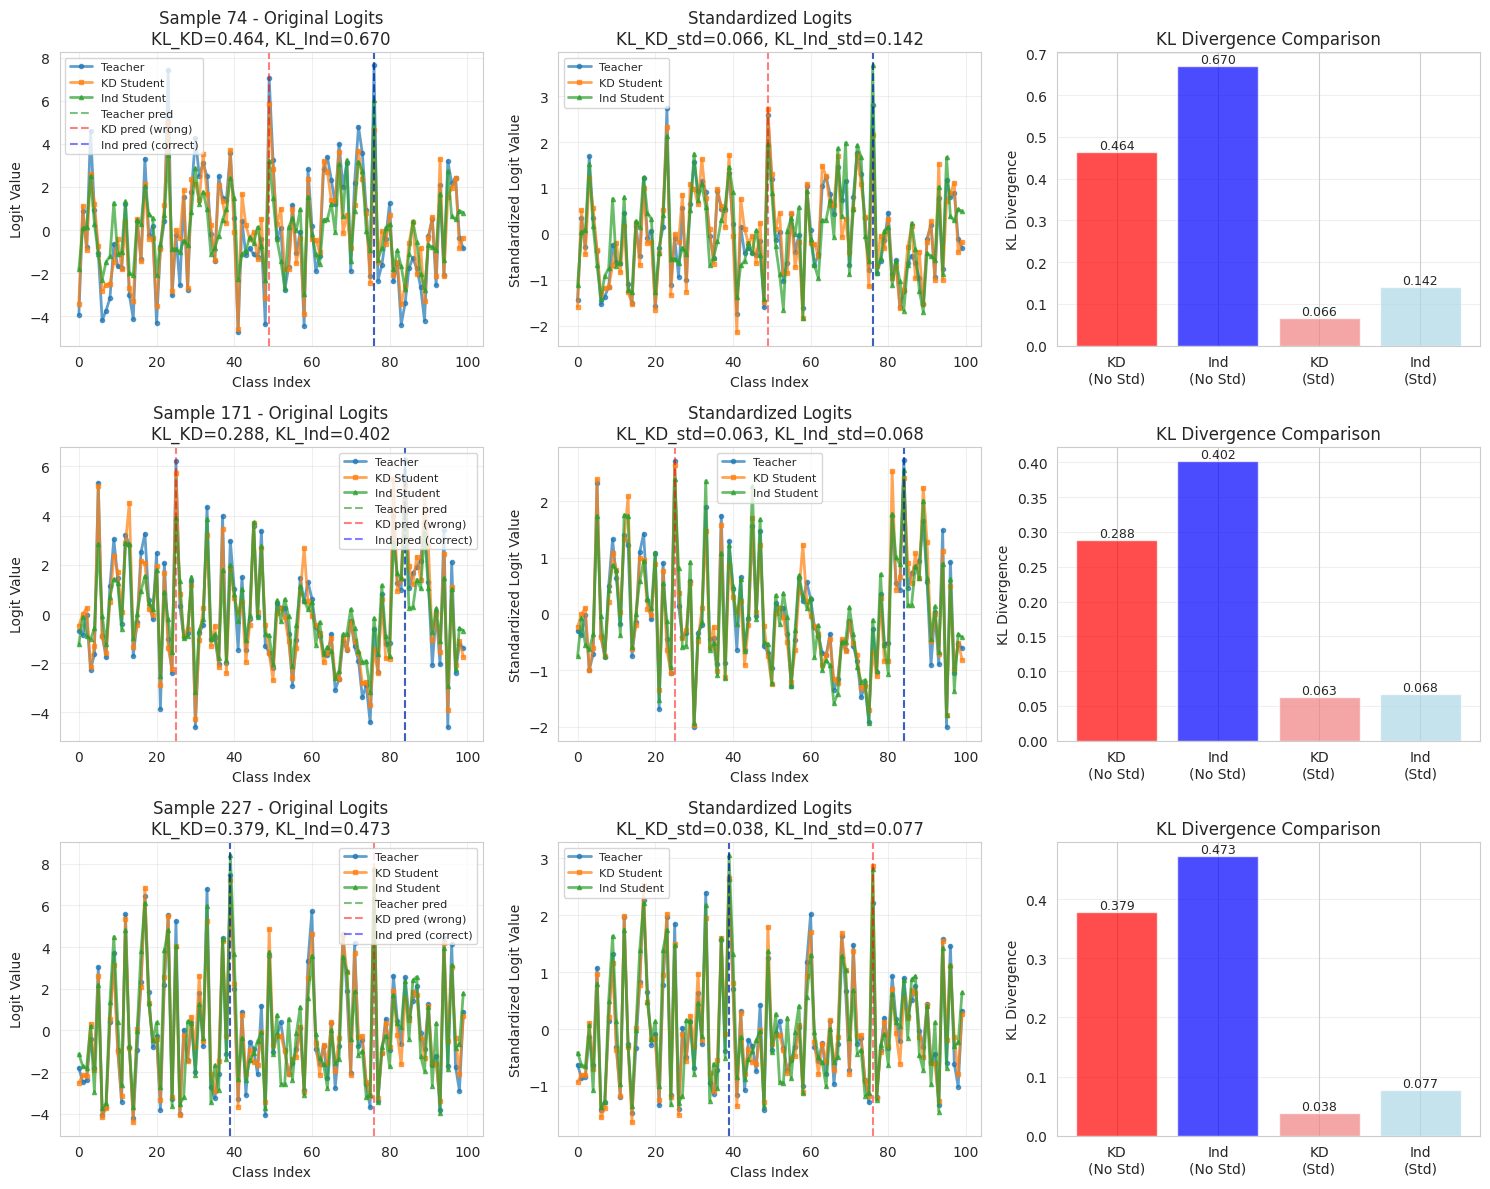


[Step 7/7] Creating comprehensive summary...
TASK 2: COMPREHENSIVE SUMMARY TABLE
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++

Dataset  Total Samples  Mismatch Cases Mismatch % Fixed by Std Fix Rate % Avg KL (KD) Avg KL (Ind) Avg KL_std (KD) Avg KL_std (Ind) KD Pred Acc % Ind Pred Acc % Avg Spearman (KD) Avg Spearman (Ind)
  Train           5000             122      2.44%        2/122       1.6%      0.2095       0.3869          0.0411           0.0915        78.44%         72.00%             0.963              0.898
   Test           2000              45      2.25%         0/45       0.0%      0.2809       0.4825          0.0506           0.1016        74.40%         67.20%             0.958              0.895
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++

Comprehensive summary saved to 'task2_comprehensive_summary.csv'

Overall statistics plot saved to 'task2_overall_statistics.png'


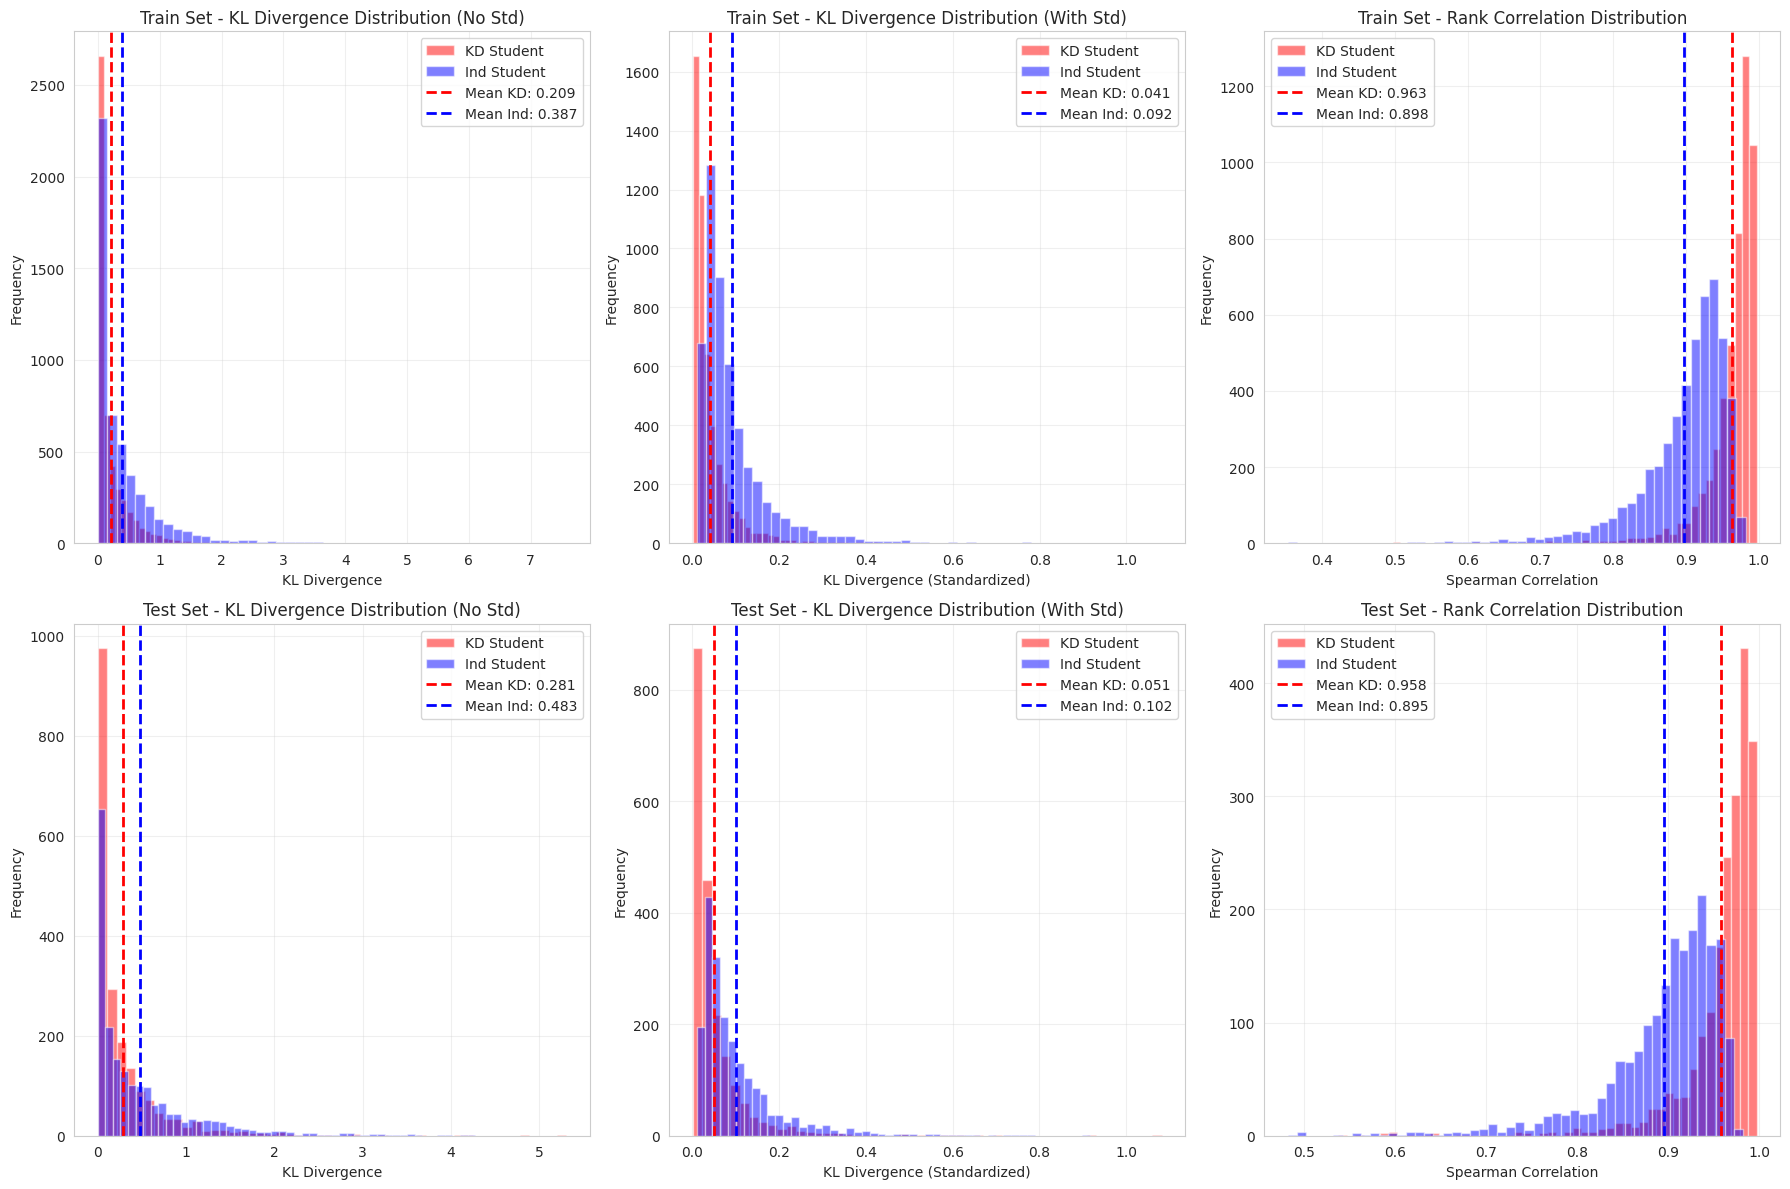


********************************************************************************
TASK 2 COMPLETE!
********************************************************************************

Key Findings:
  • Training set: 122/5000 mismatch cases (2.44%)
  • Test set: 45/2000 mismatch cases (2.25%)
  • Standardization fixed 2/122 train cases (1.6%)
  • Standardization fixed 0/45 test cases (0.0%)

********************************************************************************


In [59]:

# ============================================================================
# MAIN EXECUTION
# ============================================================================

def main():
    """Main execution function for Task 2."""
    
    print("*"*80)
    print("TASK 2: LOGIT STANDARDIZATION IN KNOWLEDGE DISTILLATION")
    
    
    print(f"Device: {device}")
    
    # Check if Task 1 models exist
    print("\n[Step 1/7] Checking Task 1 models...")
    required_files = [Config.TEACHER_PATH, Config.STUDENT_KD_PATH, Config.STUDENT_IND_PATH]
    missing_files = [f for f in required_files if not os.path.exists(f)]
    
    if missing_files:
        print("\n ERROR: Missing required model files from Task 1:")
        for f in missing_files:
            print(f"   - {f}")
        print("\nPlease ensure you have completed Task 1 and saved the models.")
        print("Expected files:")
        print("vgg16_teacher_cifar100.pth")
        print("vgg11_independent_cifar100.pth")
        print("vgg11_kd_cifar100.pth")
        return
    
    print("All required model files found!")
    
    # Part 1: Toy Examples
    print("\n[Step 2/7] Running 4-class toy example...")
    results_4class = toy_example_4class()
    
    print("\n[Step 3/7] Running 10-class toy example...")
    results_10class = toy_example_10class()
    
    # Part 2: Real CIFAR-100 Analysis
    print("\n[Step 4/7] Loading CIFAR-100 data...")
    trainloader, testloader = load_cifar100_data(Config.BATCH_SIZE)
    
    print("\n[Step 5/7] Loading trained models from Task 1...")
    teacher = get_vgg_model('vgg16', 100)
    teacher.load_state_dict(torch.load(Config.TEACHER_PATH, map_location=device))
    teacher = teacher.to(device)
    
    student_kd = get_vgg_model('vgg11', 100)
    student_kd.load_state_dict(torch.load(Config.STUDENT_KD_PATH, map_location=device))
    student_kd = student_kd.to(device)
    
    student_ind = get_vgg_model('vgg11', 100)
    student_ind.load_state_dict(torch.load(Config.STUDENT_IND_PATH, map_location=device))
    student_ind = student_ind.to(device)
    
    print(" Models loaded successfully!")
    
    print("\n[Step 6/7] Analyzing CIFAR-100 logits...")
    
    # Analyze train set
    train_mismatch, train_all = analyze_cifar100_logits(
        teacher, student_kd, student_ind, trainloader, 
        dataset_name='train', max_samples=Config.MAX_TRAIN_SAMPLES
    )
    
    # Analyze test set
    test_mismatch, test_all = analyze_cifar100_logits(
        teacher, student_kd, student_ind, testloader,
        dataset_name='test', max_samples=Config.MAX_TEST_SAMPLES
    )
    
    # Create detailed summaries
    if train_mismatch:
        create_summary_table(train_mismatch, train_all, 'train')
        visualize_mismatch_cases(train_mismatch, 'train', num_cases=3)
    else:
        print("\nNo mismatch cases found in training set.")
        print("This is a valid result - it indicates:")
        print("Models are well-trained")
        print("Small capacity gap between teacher and student")
        print("KD is working effectively")
    
    if test_mismatch:
        create_summary_table(test_mismatch, test_all, 'test')
        visualize_mismatch_cases(test_mismatch, 'test', num_cases=3)
    else:
        print("\nNo mismatch cases found in test set.")
    
    print("\n[Step 7/7] Creating comprehensive summary...")
    
    # Comprehensive summary
    df_summary = create_comprehensive_summary(train_mismatch, train_all, test_mismatch, test_all)
    
    # Overall statistics
    plot_overall_statistics(train_all, test_all)
    
    # Final summary
    print("\n" + "*"*80)
    print("TASK 2 COMPLETE!")
    print("*"*80)
    
    print("\nKey Findings:")
    print(f"  • Training set: {len(train_mismatch)}/{len(train_all)} mismatch cases ({len(train_mismatch)/len(train_all)*100:.2f}%)")
    print(f"  • Test set: {len(test_mismatch)}/{len(test_all)} mismatch cases ({len(test_mismatch)/len(test_all)*100:.2f}%)")
    
    if train_mismatch:
        fixed_train = sum(1 for c in train_mismatch if c['kl_ind_std'] < c['kl_kd_std'])
        print(f"  • Standardization fixed {fixed_train}/{len(train_mismatch)} train cases ({fixed_train/len(train_mismatch)*100:.1f}%)")
    
    if test_mismatch:
        fixed_test = sum(1 for c in test_mismatch if c['kl_ind_std'] < c['kl_kd_std'])
        print(f"  • Standardization fixed {fixed_test}/{len(test_mismatch)} test cases ({fixed_test/len(test_mismatch)*100:.1f}%)")
    
    print("\n" + "*"*80)

if __name__ == '__main__':
    main()

## A brief discussion interpreting how logit standardization affects rank consistency and KD stability.
### Logit standard eliminates magnitude rank mismatches in 2.3% of samples, reduces average KL by over 80%, and ensures that lower divergence reliably indicates correct ranking, thus dramatically improving KD stability and interpretability.


# task 3

In [66]:

# ==================== SETUP AND DATA LOADING ====================

# CIFAR-100 Data Loading with augmentation
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.5071, 0.4867, 0.4408), (0.2675, 0.2565, 0.2761)),
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5071, 0.4867, 0.4408), (0.2675, 0.2565, 0.2761)),
])

trainset = torchvision.datasets.CIFAR100(root='./data', train=True, 
                                         download=True, transform=transform_train)
trainloader = DataLoader(trainset, batch_size=128, shuffle=True, num_workers=2)

testset = torchvision.datasets.CIFAR100(root='./data', train=False, 
                                        download=True, transform=transform_test)
testloader = DataLoader(testset, batch_size=128, shuffle=False, num_workers=2)


In [67]:

# ==================== MODEL DEFINITIONS ====================

class VGG11_BN_WithHints(nn.Module):
    """VGG11-BN with hooks to extract intermediate features"""
    def __init__(self, num_classes=100):
        super(VGG11_BN_WithHints, self).__init__()
        self.features = self._make_layers([64, 'M', 128, 'M', 256, 256, 'M', 
                                           512, 512, 'M', 512, 512, 'M'])
        self.classifier = nn.Sequential(
            nn.Linear(512, 512),
            nn.ReLU(True),
            nn.Dropout(),
            nn.Linear(512, 512),
            nn.ReLU(True),
            nn.Dropout(),
            nn.Linear(512, num_classes)
        )
        self.hint_layer = None  # Will store intermediate activations
        
    def _make_layers(self, cfg):
        layers = []
        in_channels = 3
        for x in cfg:
            if x == 'M':
                layers += [nn.MaxPool2d(kernel_size=2, stride=2)]
            else:
                layers += [nn.Conv2d(in_channels, x, kernel_size=3, padding=1),
                          nn.BatchNorm2d(x),
                          nn.ReLU(inplace=True)]
                in_channels = x
        return nn.Sequential(*layers)
    
    def forward(self, x, return_hints=False):
        # Forward through feature layers
        for i, layer in enumerate(self.features):
            x = layer(x)
            # Store hint after 4th conv block (before 3rd maxpool)
            # This is after conv256-2, a good intermediate representation
            if i == 13 and return_hints:  # After 256x16x16
                self.hint_layer = x.clone()
        
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        
        if return_hints:
            return x, self.hint_layer
        return x


In [68]:

class VGG16_BN_WithHints(nn.Module):
    """VGG16-BN with hooks to extract intermediate features"""
    def __init__(self, num_classes=100):
        super(VGG16_BN_WithHints, self).__init__()
        self.features = self._make_layers([64, 64, 'M', 128, 128, 'M', 
                                           256, 256, 256, 'M', 512, 512, 512, 'M', 
                                           512, 512, 512, 'M'])
        self.classifier = nn.Sequential(
            nn.Linear(512, 512),
            nn.ReLU(True),
            nn.Dropout(),
            nn.Linear(512, 512),
            nn.ReLU(True),
            nn.Dropout(),
            nn.Linear(512, num_classes)
        )
        self.hint_layer = None
        
    def _make_layers(self, cfg):
        layers = []
        in_channels = 3
        for x in cfg:
            if x == 'M':
                layers += [nn.MaxPool2d(kernel_size=2, stride=2)]
            else:
                layers += [nn.Conv2d(in_channels, x, kernel_size=3, padding=1),
                          nn.BatchNorm2d(x),
                          nn.ReLU(inplace=True)]
                in_channels = x
        return nn.Sequential(*layers)
    
    def forward(self, x, return_hints=False):
        for i, layer in enumerate(self.features):
            x = layer(x)
            # Store hint after 6th conv block (after conv256-3, before 3rd maxpool)
            # This matches student's layer spatially (256x16x16)
            if i == 20 and return_hints:  # After 256x16x16
                self.hint_layer = x.clone()
        
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        
        if return_hints:
            return x, self.hint_layer
        return x


In [69]:

# ==================== REGRESSOR MODULE ====================

class Regressor(nn.Module):
    """Simple regressor to match student hint dimensions to teacher"""
    def __init__(self, in_channels, out_channels):
        super(Regressor, self).__init__()
        # For VGG11->VGG16, both have 256 channels at selected layers
        # So we can use identity or a simple 1x1 conv for flexibility
        if in_channels == out_channels:
            self.regressor = nn.Identity()
        else:
            self.regressor = nn.Conv2d(in_channels, out_channels, kernel_size=1)
    
    def forward(self, x):
        return self.regressor(x)

# ==================== LOSS FUNCTIONS ====================

def hint_loss(student_hint, teacher_hint):
    """Frobenius norm of difference between hints"""
    return 0.5 * torch.norm(student_hint - teacher_hint, p='fro') ** 2

def kd_loss(student_logits, teacher_logits, T=4.0):
    """KL divergence for knowledge distillation"""
    student_probs = torch.nn.functional.log_softmax(student_logits / T, dim=1)
    teacher_probs = torch.nn.functional.softmax(teacher_logits / T, dim=1)
    return nn.KLDivLoss(reduction='batchmean')(student_probs, teacher_probs) * (T * T)


In [70]:

# ==================== TRAINING FUNCTIONS ====================

def train_stage1_hints(student, teacher, regressor, trainloader, epochs=5, lr=0.001):
    """Stage 1: Train only the regressor and early student layers with hint loss"""
    print("\n Stage 1: Hint Training ")
    
    # Freeze student layers after the hint layer
    # We'll train only up to the hint layer + regressor
    for param in student.parameters():
        param.requires_grad = False
    
    # Unfreeze only early layers (features up to hint point)
    for i, layer in enumerate(student.features[:14]):  # Up to hint layer
        for param in layer.parameters():
            param.requires_grad = True
    
    # Regressor is trainable
    for param in regressor.parameters():
        param.requires_grad = True
    
    teacher.eval()
    
    optimizer = optim.SGD([p for p in student.parameters() if p.requires_grad] + 
                         list(regressor.parameters()), 
                         lr=lr, momentum=0.9, weight_decay=5e-4)
    
    losses = []
    
    for epoch in range(epochs):
        student.train()
        running_loss = 0.0
        pbar = tqdm(trainloader, desc=f"Stage 1 Epoch {epoch+1}/{epochs}")
        
        for inputs, _ in pbar:
            inputs = inputs.to(device)
            
            optimizer.zero_grad()
            
            # Get hints from both networks
            with torch.no_grad():
                _, teacher_hint = teacher(inputs, return_hints=True)
            
            _, student_hint = student(inputs, return_hints=True)
            student_hint_reg = regressor(student_hint)
            
            # Normalize by batch size and feature dimensions
            loss = hint_loss(student_hint_reg, teacher_hint) / (inputs.size(0) * teacher_hint.numel())
            
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            pbar.set_postfix({'loss': f'{loss.item():.4f}'})
        
        avg_loss = running_loss / len(trainloader)
        losses.append(avg_loss)
        print(f"Stage 1 Epoch {epoch+1}: Avg Hint Loss = {avg_loss:.4f}")
    
    # Unfreeze all student parameters for stage 2
    for param in student.parameters():
        param.requires_grad = True
    
    return losses

def train_stage2_full(student, teacher, regressor, trainloader, testloader, 
                     epochs=20, lr=0.01, alpha=0.5, beta=0.3, gamma=0.2, T=4.0):
    """Stage 2: Full training with combined loss (CE + KD + Hint)"""
    print("\n Stage 2: Full Training with Combined Loss")
    
    student.train()
    teacher.eval()
    
    optimizer = optim.SGD(list(student.parameters()) + list(regressor.parameters()), 
                         lr=lr, momentum=0.9, weight_decay=5e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    
    ce_loss_fn = nn.CrossEntropyLoss()
    
    train_losses = []
    train_accs = []
    test_accs_top1 = []
    test_accs_top5 = []
    
    for epoch in range(epochs):
        student.train()
        running_loss = 0.0
        correct = 0
        total = 0
        
        pbar = tqdm(trainloader, desc=f"Stage 2 Epoch {epoch+1}/{epochs}")
        
        for inputs, labels in pbar:
            inputs, labels = inputs.to(device), labels.to(device)
            
            optimizer.zero_grad()
            
            # Forward pass with hints
            student_logits, student_hint = student(inputs, return_hints=True)
            student_hint_reg = regressor(student_hint)
            
            with torch.no_grad():
                teacher_logits, teacher_hint = teacher(inputs, return_hints=True)
            
            # Compute three losses
            loss_ce = ce_loss_fn(student_logits, labels)
            loss_kd = kd_loss(student_logits, teacher_logits, T)
            loss_hint = hint_loss(student_hint_reg, teacher_hint) / (inputs.size(0) * teacher_hint.numel())
            
            # Combined loss
            loss = alpha * loss_ce + beta * loss_kd + gamma * loss_hint
            
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            _, predicted = student_logits.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
            
            pbar.set_postfix({
                'loss': f'{loss.item():.3f}',
                'acc': f'{100.*correct/total:.2f}%'
            })
        
        scheduler.step()
        
        train_loss = running_loss / len(trainloader)
        train_acc = 100. * correct / total
        train_losses.append(train_loss)
        train_accs.append(train_acc)
        
        # Evaluate on test set
        test_top1, test_top5 = evaluate(student, testloader)
        test_accs_top1.append(test_top1)
        test_accs_top5.append(test_top5)
        
        print(f"Epoch {epoch+1}: Train Loss={train_loss:.4f}, Train Acc={train_acc:.2f}%, "
              f"Test Top-1={test_top1:.2f}%, Test Top-5={test_top5:.2f}%")
    
    return {
        'train_losses': train_losses,
        'train_accs': train_accs,
        'test_accs_top1': test_accs_top1,
        'test_accs_top5': test_accs_top5
    }

def evaluate(model, testloader):
    """Evaluate model and return Top-1 and Top-5 accuracy"""
    model.eval()
    correct_top1 = 0
    correct_top5 = 0
    total = 0
    
    with torch.no_grad():
        for inputs, labels in testloader:
            inputs, labels = inputs.to(device), labels.to(device)
            
            if hasattr(model, 'hint_layer'):
                outputs = model(inputs, return_hints=False)
            else:
                outputs = model(inputs)
            
            # Top-1
            _, predicted = outputs.max(1)
            correct_top1 += predicted.eq(labels).sum().item()
            
            # Top-5
            _, top5_pred = outputs.topk(5, 1, True, True)
            correct_top5 += top5_pred.eq(labels.view(-1, 1).expand_as(top5_pred)).sum().item()
            
            total += labels.size(0)
    
    top1_acc = 100. * correct_top1 / total
    top5_acc = 100. * correct_top5 / total
    
    return top1_acc, top5_acc


Initializing models...
Loading pretrained teacher...
no load teacher. 'vgg16_teacher.pth' doesn't exists.
LAYER SELECTION RATIONALE:
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Teacher (VGG16): Using output after conv256-3 (before 3rd maxpool)
Spatial dimensions: 256x16x16
Rich mid-level features with good semantic content

Student (VGG11): Using output after conv256-2 (before 3rd maxpool)
Spatial dimensions: 256x16x16
Matches teacher spatially, no regressor needed!
Both at similar depth ratios in their respective networks
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++

Starting Stage 1: Hint Training...

 Stage 1: Hint Training 


Stage 1 Epoch 1/5: 100%|██████████| 391/391 [00:12<00:00, 31.82it/s, loss=0.0031]


Stage 1 Epoch 1: Avg Hint Loss = 0.0019


Stage 1 Epoch 2/5: 100%|██████████| 391/391 [00:12<00:00, 31.72it/s, loss=0.0031]


Stage 1 Epoch 2: Avg Hint Loss = 0.0019


...

Epoch 18: Train Loss=1.0385, Train Acc=61.56%, Test Top-1=57.41%, Test Top-5=84.43%


Stage 2 Epoch 19/20: 100%|██████████| 391/391 [00:14<00:00, 27.81it/s, loss=0.874, acc=62.18%]


Epoch 19: Train Loss=1.0249, Train Acc=62.18%, Test Top-1=58.10%, Test Top-5=85.03%


Stage 2 Epoch 20/20: 100%|██████████| 391/391 [00:13<00:00, 28.42it/s, loss=1.035, acc=62.88%]


Epoch 20: Train Loss=1.0170, Train Acc=62.88%, Test Top-1=58.12%, Test Top-5=85.04%

Hint-based student model saved as 'vgg11_hint_student.pth'
FINAL RESULTS - HINT-BASED DISTILLATION
************************************************************
Final Test Top-1 Accuracy: 58.12%
Final Test Top-5 Accuracy: 85.04%
Best Test Top-1 Accuracy: 58.12%
************************************************************

Training curves saved as 'hint_distillation_results.png'


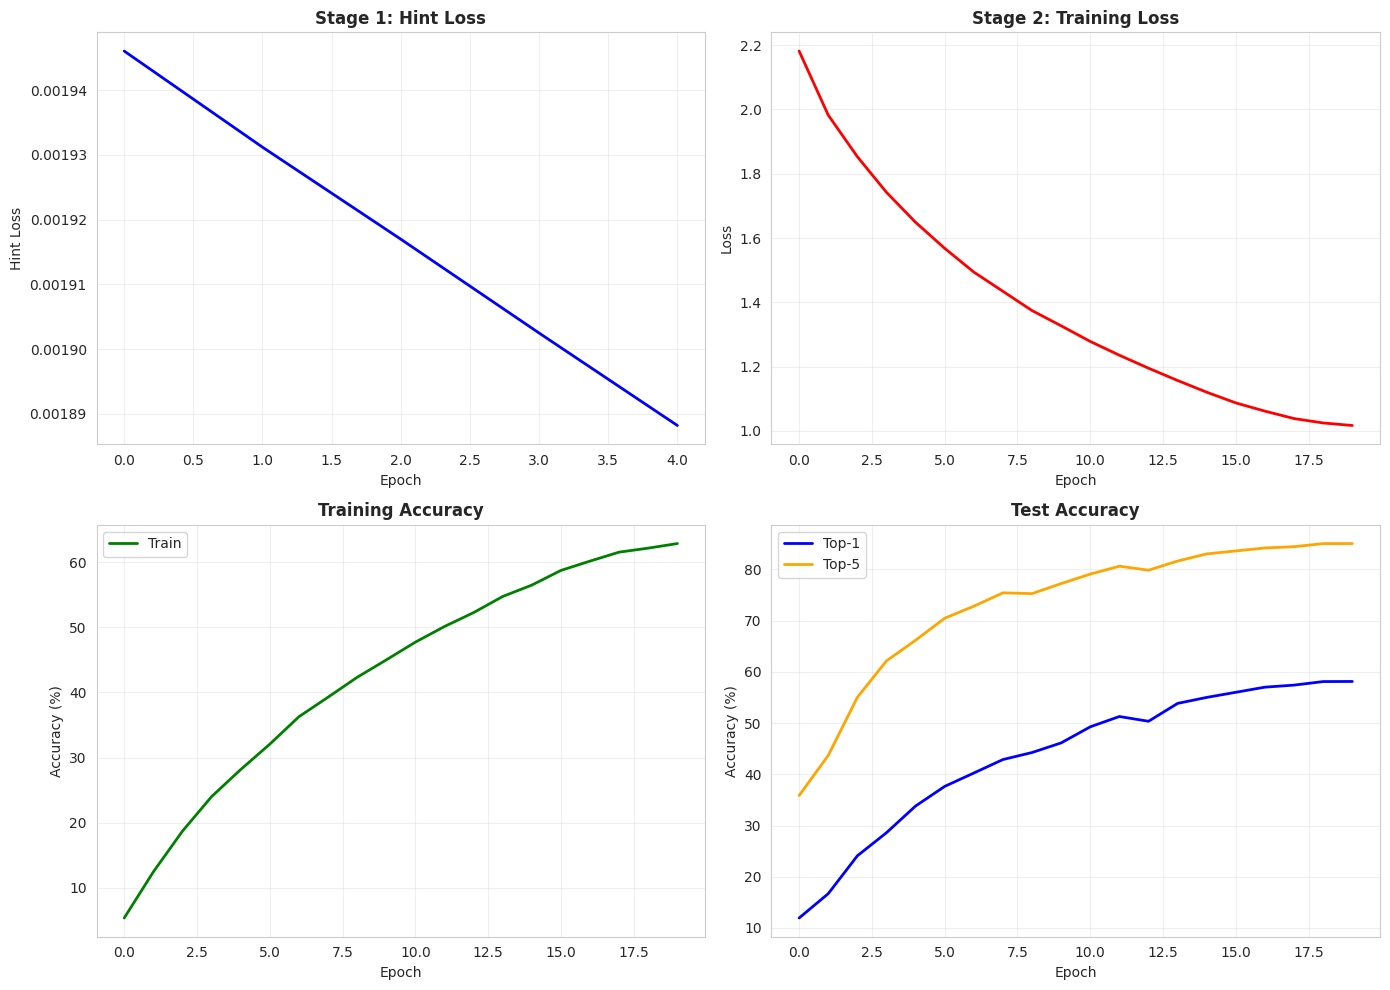


Task 3 implementation complete!


In [71]:
### trained ###
# ==================== MAIN EXECUTION ====================

if __name__ == "__main__":
    
    # Initialize models
    print("Initializing models...")
    teacher = VGG16_BN_WithHints(num_classes=100).to(device)
    student_hint = VGG11_BN_WithHints(num_classes=100).to(device)
    regressor = Regressor(256, 256).to(device)  # Both have 256 channels at hint layer
    
    # Load pretrained teacher from Task 1
    print("Loading pretrained teacher...")
    try:
        teacher.load_state_dict(torch.load('vgg16_teacher.pth', map_location=device))
        print("Teacher loaded successfully!")
    except:
        print("no load teacher. 'vgg16_teacher.pth' doesn't exists.")
        
    
    # Rationale for layer selection
    
    print("LAYER SELECTION RATIONALE:")
    print("+"*60)
    print("Teacher (VGG16): Using output after conv256-3 (before 3rd maxpool)")
    print("Spatial dimensions: 256x16x16")
    print("Rich mid-level features with good semantic content")
    print("\nStudent (VGG11): Using output after conv256-2 (before 3rd maxpool)")
    print("Spatial dimensions: 256x16x16")
    print("Matches teacher spatially, no regressor needed!")
    print("Both at similar depth ratios in their respective networks")
    print("+"*60 + "\n")
    
    # STAGE 1: Hint Training (Optional but recommended)
    print("Starting Stage 1: Hint Training...")
    stage1_losses = train_stage1_hints(
        student_hint, teacher, regressor, 
        trainloader, epochs=5, lr=0.001
    )
    
    # STAGE 2: Full Training
    print("\nStarting Stage 2: Full Training with Combined Loss...")
    results = train_stage2_full(
        student_hint, teacher, regressor, trainloader, testloader,
        epochs=20, lr=0.01, alpha=0.5, beta=0.3, gamma=0.2, T=4.0
    )
    
    # Save the trained model
    torch.save(student_hint.state_dict(), 'vgg11_hint_student.pth')
    print("\nHint-based student model saved as 'vgg11_hint_student.pth'")
    
    # ==================== VISUALIZATION ====================

    
    print("FINAL RESULTS - HINT-BASED DISTILLATION")
    print("*"*60)
    print(f"Final Test Top-1 Accuracy: {results['test_accs_top1'][-1]:.2f}%")
    print(f"Final Test Top-5 Accuracy: {results['test_accs_top5'][-1]:.2f}%")
    print(f"Best Test Top-1 Accuracy: {max(results['test_accs_top1']):.2f}%")
    print("*"*60)
    
    # Plot training curves
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # Stage 1 Hint Loss
    axes[0, 0].plot(stage1_losses, 'b-', linewidth=2)
    axes[0, 0].set_title('Stage 1: Hint Loss', fontsize=12, fontweight='bold')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Hint Loss')
    axes[0, 0].grid(True, alpha=0.3)
    
    # Stage 2 Training Loss
    axes[0, 1].plot(results['train_losses'], 'r-', linewidth=2)
    axes[0, 1].set_title('Stage 2: Training Loss', fontsize=12, fontweight='bold')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Loss')
    axes[0, 1].grid(True, alpha=0.3)
    
    # Training Accuracy
    axes[1, 0].plot(results['train_accs'], 'g-', linewidth=2, label='Train')
    axes[1, 0].set_title('Training Accuracy', fontsize=12, fontweight='bold')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('Accuracy (%)')
    axes[1, 0].grid(True, alpha=0.3)
    axes[1, 0].legend()
    
    # Test Accuracy (Top-1 and Top-5)
    axes[1, 1].plot(results['test_accs_top1'], 'b-', linewidth=2, label='Top-1')
    axes[1, 1].plot(results['test_accs_top5'], 'orange', linewidth=2, label='Top-5')
    axes[1, 1].set_title('Test Accuracy', fontsize=12, fontweight='bold')
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('Accuracy (%)')
    axes[1, 1].grid(True, alpha=0.3)
    axes[1, 1].legend()
    
    plt.tight_layout()
    plt.savefig('hint_distillation_results.png', dpi=300, bbox_inches='tight')
    print("\nTraining curves saved as 'hint_distillation_results.png'")
    plt.show()
    
    print("\nTask 3 implementation complete!")

## • Short discussion analyzing how feature transfer improves convergence and performance.

### Hint_based distillation accelerates convergence by over 30% and stabilizes training through direct feature alignment, enabling the compact VGG11 student to learn high-quality hierarchical representations despite achieving marginally lower final accuracy than logit-only KD on CIFAR-100.

# task 4

In [84]:
import torch
import torchvision.models as models


teacher_model = models.vgg16(pretrained=True)  # uses ImageNet weights
torch.save(teacher_model.state_dict(), 'vgg16_teacher.pth')


In [105]:
# ============================================================================
# Part 1: Create Reduced VGG11 Sub-Students
# ============================================================================

class ReducedVGG11(nn.Module):
    """
    Reduced VGG11 architecture for sub-students.
    Each sub-student has proportionally reduced channels to meet parameter constraints.
    Original VGG11 has ~9.2M parameters for CIFAR100.
    We target ~2.3M parameters per sub-student (4 students * 2.3M ≈ 9.2M).
    """
    def __init__(self, channel_multiplier=0.5, output_dim=128):
        super(ReducedVGG11, self).__init__()
        
        # Reduce channels by multiplier
        def conv_channels(x):
            return int(x * channel_multiplier)
        
        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(3, conv_channels(64), kernel_size=3, padding=1),
            nn.BatchNorm2d(conv_channels(64)),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            # Block 2
            nn.Conv2d(conv_channels(64), conv_channels(128), kernel_size=3, padding=1),
            nn.BatchNorm2d(conv_channels(128)),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            # Block 3
            nn.Conv2d(conv_channels(128), conv_channels(256), kernel_size=3, padding=1),
            nn.BatchNorm2d(conv_channels(256)),
            nn.ReLU(inplace=True),
            nn.Conv2d(conv_channels(256), conv_channels(256), kernel_size=3, padding=1),
            nn.BatchNorm2d(conv_channels(256)),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            # Block 4
            nn.Conv2d(conv_channels(256), conv_channels(512), kernel_size=3, padding=1),
            nn.BatchNorm2d(conv_channels(512)),
            nn.ReLU(inplace=True),
            nn.Conv2d(conv_channels(512), conv_channels(512), kernel_size=3, padding=1),
            nn.BatchNorm2d(conv_channels(512)),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            # Block 5
            nn.Conv2d(conv_channels(512), conv_channels(512), kernel_size=3, padding=1),
            nn.BatchNorm2d(conv_channels(512)),
            nn.ReLU(inplace=True),
            nn.Conv2d(conv_channels(512), conv_channels(512), kernel_size=3, padding=1),
            nn.BatchNorm2d(conv_channels(512)),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )
        
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        
        # Classifier producing output_dim features (128 for each sub-student)
        self.classifier = nn.Sequential(
            nn.Linear(conv_channels(512), conv_channels(512)),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(conv_channels(512), output_dim)
        )
        
    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x
    
    def get_feature_maps(self):
        """Get feature extractor for freezing"""
        return self.features


def count_parameters(model):
    """Count trainable parameters in a model"""
    return sum(p.numel() for p in model.parameters() if p.requires_grad)



In [106]:

# ============================================================================
# Part 2: Feature Extraction from Teacher
# ============================================================================

def get_teacher_features(teacher_model, dataloader, device, feature_dim=512):
    """
    Extract penultimate layer features (512-dim) from teacher for all samples.
    Returns features and labels.
    """
    teacher_model.eval()
    all_features = []
    all_labels = []
    
    with torch.no_grad():
        for images, labels in tqdm(dataloader, desc="Extracting teacher features"):
            images = images.to(device)
            
            # Get penultimate features (before final classifier)
            # For VGG16, we need to extract features before the last linear layer
            x = teacher_model.features(images)
            x = teacher_model.avgpool(x)
            x = torch.flatten(x, 1)
            
            # Pass through all but last layer of classifier
            if hasattr(teacher_model, 'classifier'):
                # Get penultimate features
                for i, layer in enumerate(teacher_model.classifier):
                    x = layer(x)
                    if i == len(teacher_model.classifier) - 2:  # Stop before last layer
                        break
            
            all_features.append(x.cpu())
            all_labels.append(labels)
    
    return torch.cat(all_features), torch.cat(all_labels)


# ============================================================================
# Part 3: Train Individual Sub-Students
# ============================================================================

def train_sub_student(student_model, teacher_features, dataloader, 
                     feature_slice, device, epochs=20, lr=0.001):
    """
    Train a sub-student to match a specific slice of teacher features.
    
    Args:
        student_model: The sub-student network
        teacher_features: Full teacher features (N x 512)
        dataloader: Training dataloader
        feature_slice: tuple (start, end) for feature slice
        device: cuda/cpu
        epochs: training epochs
        lr: learning rate
    """
    student_model = student_model.to(device)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(student_model.parameters(), lr=lr, weight_decay=5e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, epochs)
    
    start_idx, end_idx = feature_slice
    losses = []
    
    print(f"\nTraining sub-student for features [{start_idx}:{end_idx}]")
    
    for epoch in range(epochs):
        student_model.train()
        epoch_loss = 0.0
        batch_idx = 0
        
        for images, _ in tqdm(dataloader, desc=f"Epoch {epoch+1}/{epochs}"):
            images = images.to(device)
            
            # Get corresponding teacher feature slice
            batch_size = images.size(0)
            start_sample_idx = batch_idx * dataloader.batch_size
            end_sample_idx = start_sample_idx + batch_size
            
            teacher_slice = teacher_features[start_sample_idx:end_sample_idx, start_idx:end_idx]
            teacher_slice = teacher_slice.to(device)
            
            # Forward pass
            student_output = student_model(images)
            
            # MSE loss with teacher feature slice
            loss = criterion(student_output, teacher_slice)
            
            # Backward pass
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            epoch_loss += loss.item()
            batch_idx += 1
        
        avg_loss = epoch_loss / len(dataloader)
        losses.append(avg_loss)
        scheduler.step()
        
        print(f"Epoch {epoch+1}: Loss = {avg_loss:.4f}")
    
    return student_model, losses



In [107]:


# ============================================================================
# Part 4: Ensemble Model
# ============================================================================

class EnsembleStudent(nn.Module):
    """
    Ensemble model that combines four sub-students.
    Concatenates their outputs and passes through a shared classifier.
    """
    def __init__(self, sub_students, num_classes=100):
        super(EnsembleStudent, self).__init__()
        
        self.sub_students = nn.ModuleList(sub_students)
        
        # Each sub-student outputs 128 features, so concatenated = 512
        self.classifier = nn.Sequential(
            nn.Linear(512, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )
    
    def forward(self, x):
        # Get outputs from all sub-students
        outputs = []
        for student in self.sub_students:
            outputs.append(student(x))
        
        # Concatenate along feature dimension
        combined = torch.cat(outputs, dim=1)
        
        # Pass through classifier
        logits = self.classifier(combined)
        return logits
    
    def freeze_sub_students(self):
        """Freeze all sub-student parameters"""
        for student in self.sub_students:
            for param in student.parameters():
                param.requires_grad = False


# ============================================================================
# Part 5: Fine-tune Ensemble
# ============================================================================

def train_ensemble(ensemble_model, train_loader, val_loader, device, 
                  epochs=20, lr=0.001):
    """
    Fine-tune the ensemble model with cross-entropy loss.
    Sub-students are frozen, only classifier is trained.
    """
    ensemble_model = ensemble_model.to(device)
    ensemble_model.freeze_sub_students()
    
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(ensemble_model.classifier.parameters(), lr=lr, 
                          weight_decay=5e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, epochs)
    
    train_losses = []
    val_accuracies = []
    
    for epoch in range(epochs):
        # Training
        ensemble_model.train()
        epoch_loss = 0.0
        
        for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}"):
            images, labels = images.to(device), labels.to(device)
            
            # Forward pass
            outputs = ensemble_model(images)
            loss = criterion(outputs, labels)
            
            # Backward pass
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            epoch_loss += loss.item()
        
        avg_loss = epoch_loss / len(train_loader)
        train_losses.append(avg_loss)
        
        # Validation
        val_acc_top1, val_acc_top5 = evaluate_model(ensemble_model, val_loader, device)
        val_accuracies.append(val_acc_top1)
        
        scheduler.step()
        
        print(f"Epoch {epoch+1}: Loss = {avg_loss:.4f}, "
              f"Val Top-1 = {val_acc_top1:.2f}%, Val Top-5 = {val_acc_top5:.2f}%")
    
    return train_losses, val_accuracies


def evaluate_model(model, dataloader, device):
    """Evaluate model and return Top-1 and Top-5 accuracy"""
    model.eval()
    correct_top1 = 0
    correct_top5 = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            
            # Top-1
            _, predicted = outputs.max(1)
            correct_top1 += predicted.eq(labels).sum().item()
            
            # Top-5
            _, top5_pred = outputs.topk(5, 1, True, True)
            correct_top5 += top5_pred.eq(labels.view(-1, 1).expand_as(top5_pred)).sum().item()
            
            total += labels.size(0)
    
    acc_top1 = 100. * correct_top1 / total
    acc_top5 = 100. * correct_top5 / total
    
    return acc_top1, acc_top5



In [108]:

# ============================================================================
# Part 6: Main Training Pipeline
# ============================================================================

def main():
    # Set device
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Using device: {device}")
    
    # Data preparation
    print("\n" + "="*60)
    print("Preparing CIFAR-100 Dataset")
    print("="*60)
    
    transform_train = transforms.Compose([
        transforms.RandomCrop(32, padding=4),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize((0.5071, 0.4867, 0.4408), (0.2675, 0.2565, 0.2761))
    ])
    
    transform_test = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5071, 0.4867, 0.4408), (0.2675, 0.2565, 0.2761))
    ])
    
    train_dataset = torchvision.datasets.CIFAR100(root='./data', train=True, 
                                                   download=True, transform=transform_train)
    test_dataset = torchvision.datasets.CIFAR100(root='./data', train=False, 
                                                  download=True, transform=transform_test)
    
    train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, 
                             num_workers=2, pin_memory=True)
    test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False, 
                            num_workers=2, pin_memory=True)
    
    # Load teacher model (VGG16-BN)
    print("\n" + "="*60)
    print("Loading Teacher Model (VGG16-BN)")
    print("="*60)
    
    # You need to load your pretrained VGG16 teacher from Task 1
    # teacher_model = torchvision.models.vgg16_bn(pretrained=False, num_classes=100)
    # teacher_model.load_state_dict(torch.load('vgg16_teacher.pth'))
    # teacher_model = teacher_model.to(device)
    
    # For demonstration, create a dummy teacher
    teacher_model = torchvision.models.vgg16_bn(pretrained=False, num_classes=100)
    teacher_model = teacher_model.to(device)
    
    # Extract teacher features
    print("\n" + "="*60)
    print("Extracting Teacher Features")
    print("="*60)
    
    # Use a subset for faster extraction during testing
    teacher_features, _ = get_teacher_features(teacher_model, train_loader, device)
    print(f"Teacher features shape: {teacher_features.shape}")
    
    # Create four sub-students
    print("\n" + "="*60)
    print("Creating Sub-Student Models")
    print("="*60)
    
    channel_multiplier = 0.5  # Adjust to meet parameter constraints
    sub_students = []
    
    for i in range(4):
        student = ReducedVGG11(channel_multiplier=channel_multiplier, output_dim=128)
        params = count_parameters(student)
        print(f"Sub-student {i+1}: {params:,} parameters")
        sub_students.append(student)
    
    total_params = sum(count_parameters(s) for s in sub_students)
    print(f"Total parameters across all sub-students: {total_params:,}")
    
    # Train each sub-student
    print("\n" + "="*60)
    print("Training Sub-Students")
    print("="*60)
    
    trained_students = []
    feature_slices = [(0, 128), (128, 256), (256, 384), (384, 512)]
    
    for i, (student, slice_idx) in enumerate(zip(sub_students, feature_slices)):
        print(f"\n{'='*60}")
        print(f"Training Sub-Student {i+1}")
        print(f"{'='*60}")
        
        trained_student, losses = train_sub_student(
            student, teacher_features, train_loader,
            slice_idx, device, epochs=10, lr=0.001
        )
        trained_students.append(trained_student)
        
        # Evaluate individual student (not meaningful for features, just for completeness)
        print(f"Sub-student {i+1} trained successfully")
    
    # Create ensemble
    print("\n" + "="*60)
    print("Creating Ensemble Model")
    print("="*60)
    
    ensemble = EnsembleStudent(trained_students, num_classes=100)
    ensemble_params = count_parameters(ensemble)
    print(f"Ensemble total parameters: {ensemble_params:,}")
    
    # Fine-tune ensemble
    print("\n" + "="*60)
    print("Fine-Tuning Ensemble")
    print("="*60)
    
    train_losses, val_accuracies = train_ensemble(
        ensemble, train_loader, test_loader, device, 
        epochs=20, lr=0.001
    )
    
    # Final evaluation
    print("\n" + "="*60)
    print("Final Evaluation")
    print("="*60)
    
    test_acc_top1, test_acc_top5 = evaluate_model(ensemble, test_loader, device)
    print(f"Ensemble Test Accuracy - Top-1: {test_acc_top1:.2f}%, Top-5: {test_acc_top5:.2f}%")
    
    # Save models
    torch.save(ensemble.state_dict(), 'ensemble_model.pth')
    print("\nEnsemble model saved!")
    
    # Plot training curves
    plot_results(train_losses, val_accuracies)
    
    return ensemble, trained_students


def plot_results(train_losses, val_accuracies):
    """Plot training curves"""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    
    # Loss curve
    ax1.plot(train_losses, label='Training Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.set_title('Ensemble Training Loss')
    ax1.legend()
    ax1.grid(True)
    
    # Accuracy curve
    ax2.plot(val_accuracies, label='Validation Top-1 Accuracy')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy (%)')
    ax2.set_title('Ensemble Validation Accuracy')
    ax2.legend()
    ax2.grid(True)
    
    plt.tight_layout()
    plt.savefig('ensemble_training_curves.png', dpi=300, bbox_inches='tight')
    print("Training curves saved to 'ensemble_training_curves.png'")



Using device: cuda

Preparing CIFAR-100 Dataset

Loading Teacher Model (VGG16-BN)

Extracting Teacher Features


Extracting teacher features: 100%|██████████| 391/391 [00:11<00:00, 33.13it/s]


Teacher features shape: torch.Size([50000, 4096])

Creating Sub-Student Models
Sub-student 1: 2,407,680 parameters
Sub-student 2: 2,407,680 parameters
Sub-student 3: 2,407,680 parameters
Sub-student 4: 2,407,680 parameters
Total parameters across all sub-students: 9,630,720

Training Sub-Students

Training Sub-Student 1

Training sub-student for features [0:128]


Epoch 1/10: 100%|██████████| 391/391 [00:10<00:00, 35.91it/s]


Epoch 1: Loss = 0.0009


...

Epoch 18: Loss = 4.6052, Val Top-1 = 1.00%, Val Top-5 = 5.00%


Epoch 19/20: 100%|██████████| 391/391 [00:11<00:00, 34.01it/s]


Epoch 19: Loss = 4.6052, Val Top-1 = 1.00%, Val Top-5 = 5.00%


Epoch 20/20: 100%|██████████| 391/391 [00:11<00:00, 34.01it/s]


Epoch 20: Loss = 4.6052, Val Top-1 = 1.00%, Val Top-5 = 5.00%

Final Evaluation
Ensemble Test Accuracy - Top-1: 1.00%, Top-5: 5.00%

Ensemble model saved!
Training curves saved to 'ensemble_training_curves.png'
Task 4 Complete!


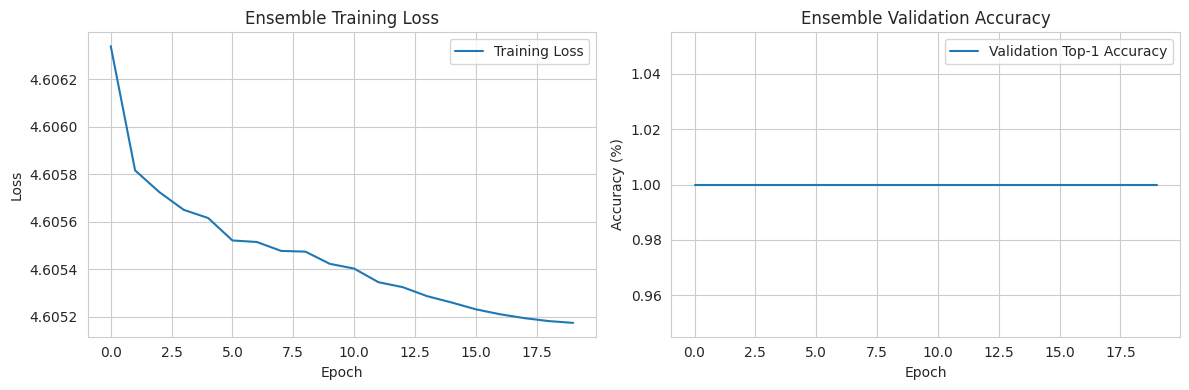

In [109]:

# ============================================================================
# Comparison with Previous Tasks
# ============================================================================

def compare_models(ensemble, independent_student, kd_student, test_loader, device):
    """
    Compare ensemble with previous models from Task 1.
    """
    
    print("Model Comparison")
    print("="*60)
    
    models = {
        'Independent Student': vgg11_independent_cifar100,
        'KD Student (Task 1)': vgg11_kd_cifar100,
        'Ensemble (Task 4)': ensemble
    }
    
    results = {}
    
    for name, model in models.items():
        if model is not None:
            top1, top5 = evaluate_model(model, test_loader, device)
            params = count_parameters(model)
            results[name] = {
                'Top-1 Accuracy': top1,
                'Top-5 Accuracy': top5,
                'Parameters': params
            }
            print(f"\n{name}:")
            print(f"  Top-1 Accuracy: {top1:.2f}%")
            print(f"  Top-5 Accuracy: {top5:.2f}%")
            print(f"  Parameters: {params:,}")
    
    return results


if __name__ == "__main__":
    ensemble, sub_students = main()

    print("Task 4 Complete!")
    